# Introduction


# Bank and Marketing Prediction

This capstone presents a complete **machine learning project** built around a real business problem. The objective is to predict whether a **bank client** will **subscribe** to a **term deposit** after a **direct marketing phone campaign**. The dataset comes from a **Portuguese banking institution** and includes **45,211 client records** with **16 input features** and **one binary target variable**.


***
1. **Problem Framing:**
Translate the business objective into a binary classification task to predict whether a client will subscribe to a term deposit.

2. **Data Understanding & Preparation:**
Analyze demographic, financial, and campaign-related features. Perform data cleaning, encode categorical variables, and carefully handle campaign-specific information.

3. **Modeling:**
Evaluate multiple classification algorithms (e.g., logistic regression, decision trees, ensemble methods). Assess performance using precision, recall, and F1 score, considering class imbalance and business impact.

4. **Critical Analysis:**
Examine potential demographic bias, data limitations, overfitting risks, and the business consequences of prediction errors.

5. **Communication & Deployment:**
Present results in clear business terms and prepare the model for deployment to improve marketing efficiency and reduce operational costs.
***
This capstone demonstrates the ability to move from raw data to actionable business insight through structured analysis, sound modeling, and clear communication.



## Step 1: **Problem Understanding**

### **Problem Statement**
<div style="text-align: justify;">

> **Phone marketing campaigns** are **expensive** and **time-consuming**, but only **11.7%** of clients in this dataset subscribe to a term deposit **(5,289 out of 45,211)**. Calling the wrong clients **increases operational costs** and **reduces campaign efficiency**. This project aims to help the bank **target clients** by predicting who is most **likely to subscribe**.


> This is a **binary classification problem**, where the model predicts whether a **client will subscribe** (yes or no). Due to strong class imbalance **(88.3% non-subscribers)**, accuracy is not an appropriate metric: a naive model predicting "no" for all clients would achieve 88% accuracy without delivering business value. Instead, performance will be evaluated using **F1-score** and **AUC-ROC** to balance precision and recall.

> From a business perspective, **false positives** increase operational call costs, while **false negatives** represent lost revenue opportunities. Therefore, success is defined by **improved conversion rate**s, **reduced unnecessary calls**, and **increased campaign ROI**. The model will ultimately support **decision-making by ranking** clients based on predicted probability, allowing the bank to **prioritize high-likelihood customers**.

</div>

## Step 2: **Data Collection & Understanding**

In [1]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import (
    recall_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)

from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier

import shap
import os
import joblib
from datetime import datetime
from google.colab import drive

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Sample Bank Data from "MyDrive"
dfbank = pd.read_csv('/content/drive/MyDrive/data/bank/bank.csv', sep=';')
dfbank.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no


In [4]:
# Load Full Bank Data from "MyDrive"
dfbankfull = pd.read_csv('/content/drive/MyDrive/data/bank/bank-full.csv', sep=';')
dfbankfull.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


### **Dataset Collection & Justification**

The dataset used in this project is the **Bank Marketing Dataset**, publicly available and originally published by **Moro et al. (2011)**. It contains real-world data from direct marketing campaigns conducted by a Portuguese banking institution between **May 2008** and **November 2010**.

The dataset is widely used in machine learning research for classification problems and follows the CRISP-DM methodology, making it a high-quality and well-documented source for predictive modeling.


**Reference:**

  -  **Moro, S., Laureano, R., & Cortez, P.** (2011). *Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology*. European Simulation and Modelling Conference (ESM 2011).



### **Dataset Overview**
The full dataset (bank-full.csv) contains:

- **45,211 instances**
- **16 input features**
- **1 binary target variable (y)**

The objective is to predict whether the client will subscribe to a term deposit.

**Target Variable Distribution**
The target variable y is binary:

- No: **39,922 (88.3%)**
- Yes: **5,289 (11.7%)**

This confirms a strong class imbalance, which must be considered during modeling and evaluation.



**Feature Types**

The dataset contains a mix of:

- **Numerical variables**: `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`

- **Categorical variables**: `job`, `marital`, `education`, `contact`, `month`, `poutcome`

- **Binary variables**: `default`, `housing`, `loan`

- **Target variable**: `y` (binary: yes/no)

This mix requires encoding of categorical features and careful scaling of numerical features during preprocessing.



**Missing Values**

There are no explicit missing values (**NaN**) in the dataset. However, some categorical variables contain the value "**unknown**", which represents missing or unavailable information. These entries will be handled appropriately during preprocessing.



**Numerical Feature Characteristics & Distributions**

- **Age**: Ranges from young adults to retirees, with a moderately right-skewed distribution.
- **Balance**: Contains both positive and negative values, indicating overdrafts; highly skewed with potential outliers.
- **Duration**: Strongly right-skewed, with many short calls and fewer long calls. This variable is highly predictive but is only known after the call is completed; therefore, it may introduce data leakage if the objective is pre-call targeting.
- **Campaign** / Previous: Long-tailed distributions, as some clients were contacted multiple times.

Several numerical variables exhibit skewness and potential outliers that may affect model stability and predictive performance. In particular, extreme values in balance and duration may require transformation or robust scaling.

### **Data Dictionary**
| Variable Name | Type | Description | Allowed Values |
|---------------|------|-------------|----------------|
| `age` | Integer | Age of the client in years | Numeric |
| `job` | Categorical | Type of job | "admin", "unknown", "unemployed", "management", "housemaid", "entrepreneur", "student", "blue-collar", "self-employed", "retired", "technician", "services" |
| `marital` | Categorical | Marital status | "married", "divorced", "single" |
| `education` | Categorical | Education level | "unknown", "secondary", "primary", "tertiary" |
| `default` | Binary | Has credit in default | "yes", "no" |
| `balance` | Integer | Average yearly balance in euros | Numeric, may include negative values |
| `housing` | Binary | Has housing loan | "yes", "no" |
| `loan` | Binary | Has personal loan | "yes", "no" |
| `contact` | Categorical | Contact communication type | "unknown", "telephone", "cellular" |
| `day` | Integer | Last contact day of the month | 1-31 |
| `month` | Categorical | Last contact month of year | "jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec" |
| `duration` | Integer | Last contact duration in seconds | Numeric, 0 and above |
| `campaign` | Integer | Number of contacts during current campaign for this client | Numeric, 1 and above |
| `pdays` | Integer | Number of days since client was last contacted from a previous campaign | -1 (indicates no previous contact) or positive integer |
| `previous` | Integer | Number of contacts before this campaign for this client | Numeric, 0 and above |
| `poutcome` | Categorical | Outcome of the previous marketing campaign | "unknown", "other", "failure", "success" |
| `y` | Binary | Has the client subscribed a term deposit | "yes", "no" |

## Step 3: **Data Preprocessing, EDA & Feature Engineering**

### 3a. Data Cleaning
-  [Handling Missing Values](#scrollTo=VaYtrXs0zEw4&line=1&uniqifier=1)
-  [Remove Duplicates](#scrollTo=Y_YjvnJkzKqR&line=1&uniqifier=1)
-  [Address Outliers](#scrollTo=Nd8Jh-WLzS8r&line=1&uniqifier=1)

In [5]:
# Copy Full Bank Dataframe and show description and information about dataset
df = dfbankfull.copy()
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


T**Note**: The dataset contains 45,211 recordds and 17 variables. All variables are either numerical `int64`or categorical `object`, requiring encoding in a later preprocessing steps.

**Handling Missing Values**

In [8]:
# Check for Missing Values
print(df[df.isna().any(axis=1)].fillna("Missing").to_string(index=False))

Empty DataFrame
Columns: [age, job, marital, education, default, balance, housing, loan, contact, day, month, duration, campaign, pdays, previous, poutcome, y]
Index: []


**Note:** Confirmed that there are no explicit missing values (NaN) in the dataset. However, certain categorical variables contain the value "unknown", which represents missing or unavailable information. These wil lbe handled during encoding to preserve potential informational value.

**Remove Duplicates**

In [9]:
# Check if there are any duplicates
print("Count of Duplicated Rows:", df.duplicated().sum())

Count of Duplicated Rows: 0


**Note:** No Duplicate Values identified in the dataset so no records were removed.

**Address Outliers**

In [10]:
# Show Box Plot to Show Numeric Outliers in Data
def plot_numeric_boxplots(df, rows=1, figsize_per_plot=(2, 3)):
    numeric_cols = df.select_dtypes(include="number").columns
    n = len(numeric_cols)
    if n == 0:
        print("No numeric columns found.")
        return
    cols = math.ceil(n / rows)
    fig, axes = plt.subplots(rows,
                             cols,
                             figsize=(figsize_per_plot[0] * cols,
                                      figsize_per_plot[1] * rows))
    # Make axes iterable in all cases
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_title(col)

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

def iqr_summary_continuous(df, min_unique=10, max_zero_frac=0.95):
    num = df.select_dtypes(include="number")
    cols = []
    for c in num.columns:
        nunique = num[c].nunique(dropna=True)
        zero_frac = (num[c] == 0).mean()
        if nunique >= min_unique and zero_frac <= max_zero_frac:
            cols.append(c)

    summary = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        summary.append([col, Q1, Q3, IQR, lower, upper, outliers])

    return pd.DataFrame(summary, columns=["column","Q1","Q3","IQR","lower_bound","upper_bound","outlier_count"])

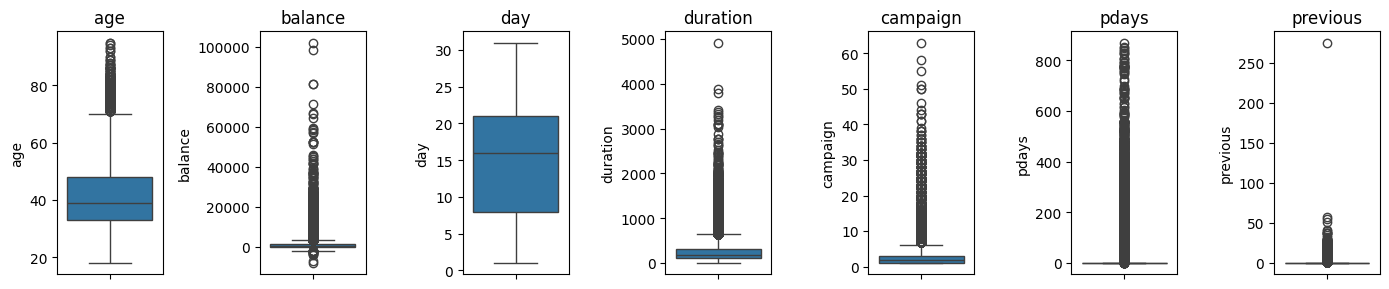

In [11]:
# Use IQR Method Before Transformation
plot_numeric_boxplots(df)

In [12]:
iqr_summary_continuous(df)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,age,33.0,48.0,15.0,10.5,70.5,487
1,balance,72.0,1428.0,1356.0,-1962.0,3462.0,4729
2,day,8.0,21.0,13.0,-11.5,40.5,0
3,duration,103.0,319.0,216.0,-221.0,643.0,3235
4,campaign,1.0,3.0,2.0,-2.0,6.0,3064
5,pdays,-1.0,-1.0,0.0,-1.0,-1.0,8257
6,previous,0.0,0.0,0.0,0.0,0.0,8257



Boxplots and IQR anlaysis  revealed significant right-skweness and extreme values in financial and duration-related variables:
- **Balance** contained 4729 outliers
- **Duration** contained 3235 outliers
- **Campaign** contained 3064 outliers

Given the business context, extreme values may represent legitimate customer behavior so removing them could distort the data. Instead of deletion, logarithmic transformations were applied to reduce skweness while prserving information.

In [13]:
 # Create Contact Flag and neutralize -1
df["previously_contacted"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].where(df["pdays"] != -1, 0)

# Transform Skewed Financial Variables
df["balance_signlog"] = np.sign(df["balance"]) * np.log1p(np.abs(df["balance"]))
df["duration_log"] = np.log1p(df["duration"])

# Transform Count / Zero-inflated Variables
df["campaign_log"] = np.log1p(df["campaign"])
df["previous_log"] = np.log1p(df["previous"])
df["pdays_log"] = np.log1p(df["pdays"])

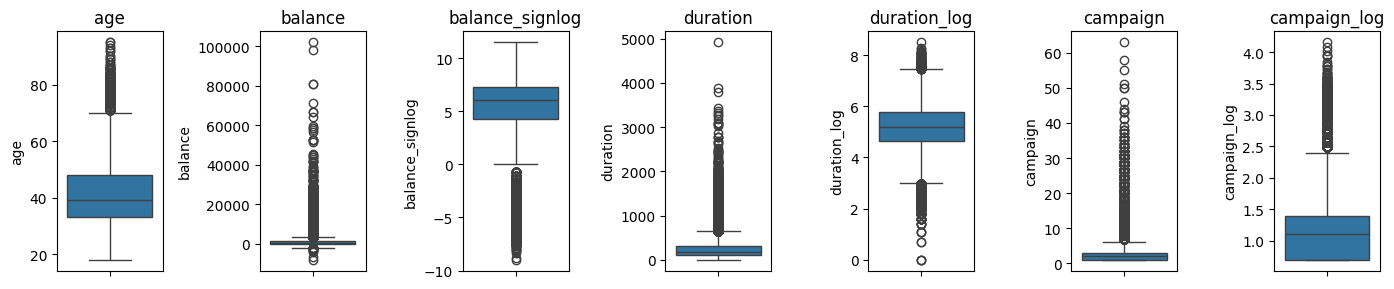

In [14]:
# Use IQR Method After Transformation
numeric_cols_iqr = ['age', 'balance', 'balance_signlog', 'duration', 'duration_log', 'campaign', 'campaign_log']
plot_numeric_boxplots(df[numeric_cols_iqr])

In [15]:
iqr_summary_continuous(df[numeric_cols_iqr])

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,age,33.000000,48.000000,15.000000,10.500000,70.500000,487
1,balance,72.000000,1428.000000,1356.000000,-1962.000000,3462.000000,4729
2,balance_signlog,4.290459,7.264730,2.974271,-0.170947,11.726136,3766
3,duration,103.000000,319.000000,216.000000,-221.000000,643.000000,3235
4,duration_log,4.644391,5.768321,1.123930,2.958496,7.454216,1238
5,campaign,1.000000,3.000000,2.000000,-2.000000,6.000000,3064
6,campaign_log,0.693147,1.386294,0.693147,-0.346574,2.426015,1196


After transformation, outlier counts decreased substantially (e.g., duration outliers reduced from 3,235 to 1,238), indicating improved distribution stability.

### 3b. Exploratory Data Analysis
- [Univariate Analysis](#scrollTo=RzEbpF6uz29v&line=1&uniqifier=1)
  - [Numerical Feautures ](#scrollTo=yQMWHZGs86lY)
  - [Categorical Features](#scrollTo=HfqCC_tX9D2k)
- [Bivariate Analysis](#scrollTo=SmbzCc0Az734)
  - [Numeric vs Numeric Features](#scrollTo=HvhaK-elj08R)
  - [Numeric vs Numeric Features (Transformed)](#scrollTo=9soLzLVukC8l&line=1&uniqifier=1)
  - [Numeric Features vs Target (y)](#scrollTo=ISfeeGCKkrrt&line=1&uniqifier=1)
  - [Numeric vs Other Categorical](#scrollTo=SDbAKEnhmIjW&line=1&uniqifier=1)
  - [Categorical vs Categorical Features](#scrollTo=wO1AUInTlwgr&line=1&uniqifier=1)
  - [Categorical Features vs Target (y)](#scrollTo=ZYa7JlWbmeOC&line=1&uniqifier=1)
  - [Correlation Analysis](#scrollTo=68oHuzsB0A3Y&line=1&uniqifier=1)


**Univariate analysis (distributions)**

In [16]:
def univariate_analysis(df, col):
    if col not in df.columns:
        print(f"{col} not found in dataframe.")
        return

    s = df[col]
    print("="*100, f"\n Univariate Analysis: {col}")
    print("="*100)

    # Missing values
    print(f"Missing values: {s.isna().sum()} ({round(100*s.isna().mean(),2)}%)")
    print(f"Unique values: {s.nunique()}")
    print()

    # Numeric variables
    if pd.api.types.is_numeric_dtype(s):
        print("Summary Statistics:")
        print(s.describe())
        print(f"Skewness: {round(s.skew(), 3)}")
        print(f"Kurtosis: {round(s.kurt(), 3)}")
        print()

        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        sns.histplot(s, kde=True, ax=axes[0])
        axes[0].set_title("Distribution")
        sns.boxplot(x=s, ax=axes[1])
        axes[1].set_title("Boxplot")
        plt.tight_layout()
        plt.show()

    # Categorical variables
    else:
        print("Value Counts:")
        print(s.value_counts())
        print()

        plt.figure(figsize=(8,3))
        sns.countplot(x=s, order=s.value_counts().index)
        plt.xticks(rotation=45)
        plt.title("Category Distribution")
        plt.tight_layout()
        plt.show()

In [17]:
numeric_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(exclude="number").columns

**Numerical Features**

 Univariate Analysis: age
Missing values: 0 (0.0%)
Unique values: 77

Summary Statistics:
count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64
Skewness: 0.685
Kurtosis: 0.32



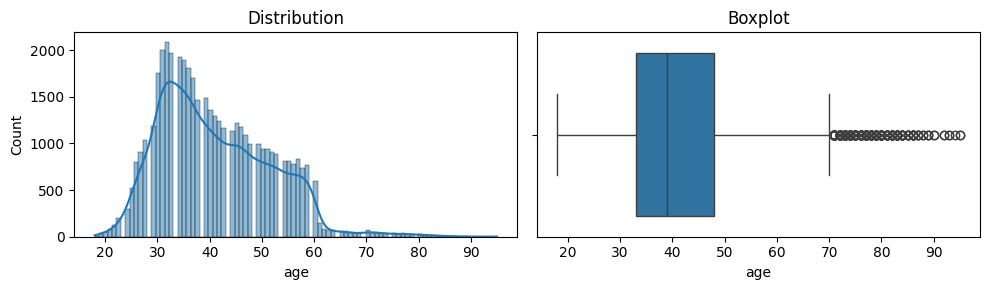

 Univariate Analysis: balance
Missing values: 0 (0.0%)
Unique values: 7168

Summary Statistics:
count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64
Skewness: 8.36
Kurtosis: 140.752



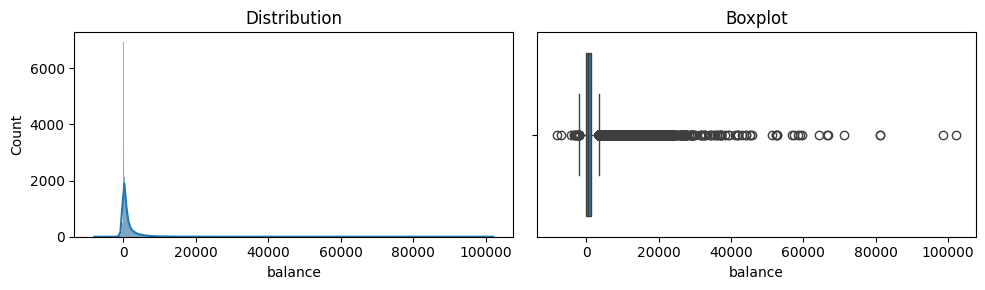

 Univariate Analysis: day
Missing values: 0 (0.0%)
Unique values: 31

Summary Statistics:
count    45211.000000
mean        15.806419
std          8.322476
min          1.000000
25%          8.000000
50%         16.000000
75%         21.000000
max         31.000000
Name: day, dtype: float64
Skewness: 0.093
Kurtosis: -1.06



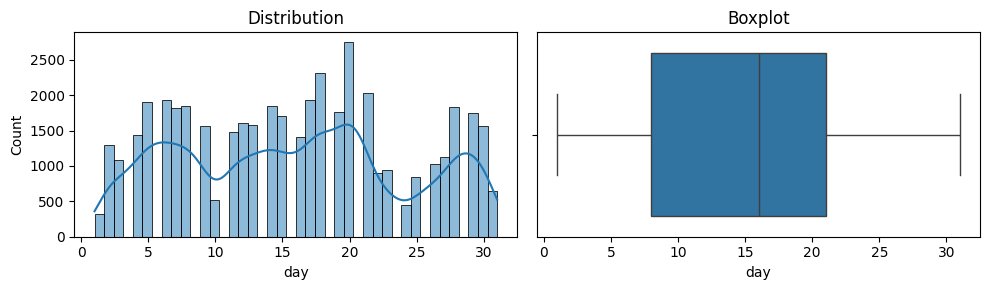

 Univariate Analysis: duration
Missing values: 0 (0.0%)
Unique values: 1573

Summary Statistics:
count    45211.000000
mean       258.163080
std        257.527812
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64
Skewness: 3.144
Kurtosis: 18.154



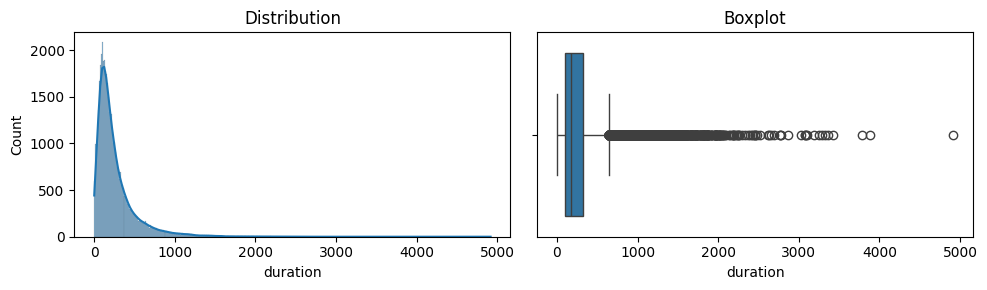

 Univariate Analysis: campaign
Missing values: 0 (0.0%)
Unique values: 48

Summary Statistics:
count    45211.000000
mean         2.763841
std          3.098021
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         63.000000
Name: campaign, dtype: float64
Skewness: 4.899
Kurtosis: 39.25



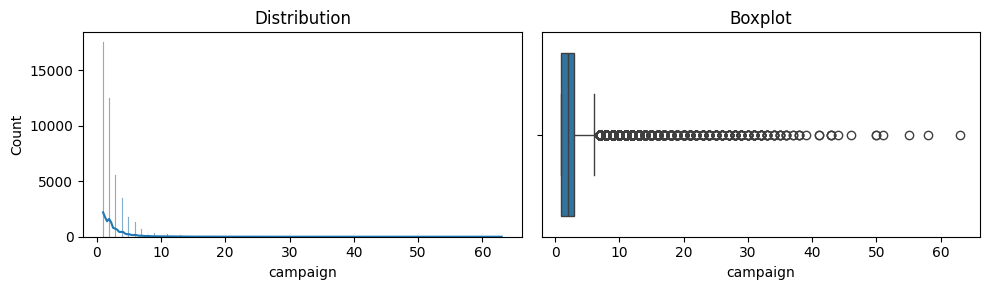

 Univariate Analysis: pdays
Missing values: 0 (0.0%)
Unique values: 559

Summary Statistics:
count    45211.000000
mean        41.015195
std         99.792615
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        871.000000
Name: pdays, dtype: float64
Skewness: 2.622
Kurtosis: 6.981



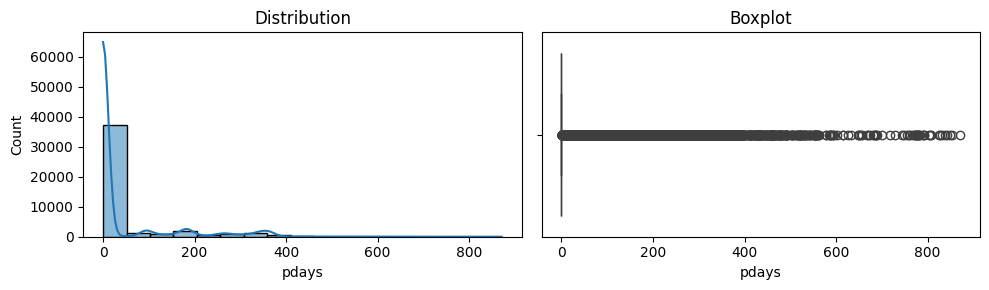

 Univariate Analysis: previous
Missing values: 0 (0.0%)
Unique values: 41

Summary Statistics:
count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64
Skewness: 41.846
Kurtosis: 4506.861



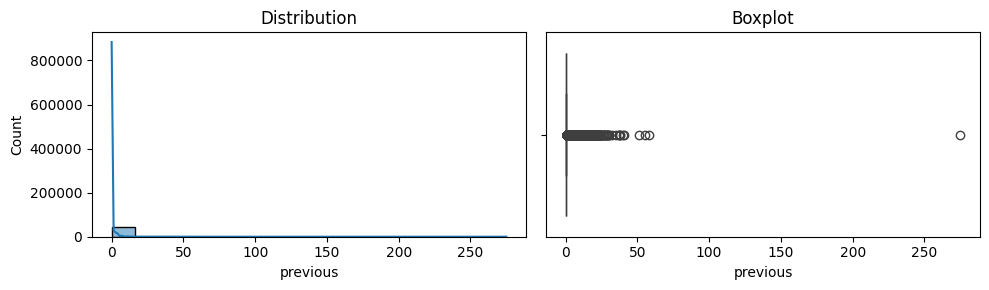

 Univariate Analysis: previously_contacted
Missing values: 0 (0.0%)
Unique values: 2

Summary Statistics:
count    45211.000000
mean         0.182633
std          0.386369
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: previously_contacted, dtype: float64
Skewness: 1.643
Kurtosis: 0.699



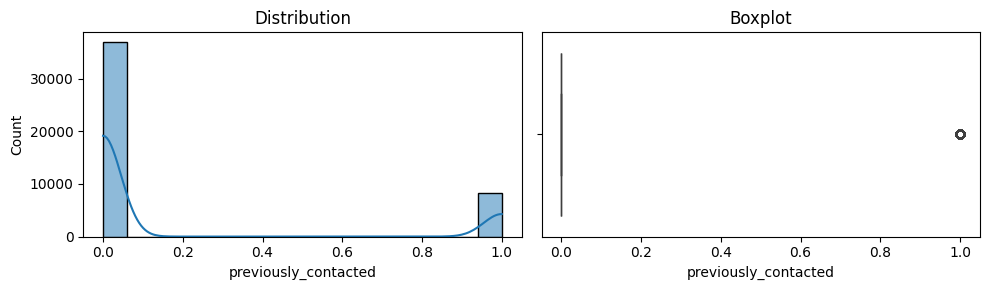

 Univariate Analysis: balance_signlog
Missing values: 0 (0.0%)
Unique values: 7168

Summary Statistics:
count    45211.000000
mean         4.887106
std          3.807660
min         -8.989694
25%          4.290459
50%          6.107023
75%          7.264730
max         11.533982
Name: balance_signlog, dtype: float64
Skewness: -1.583
Kurtosis: 1.83



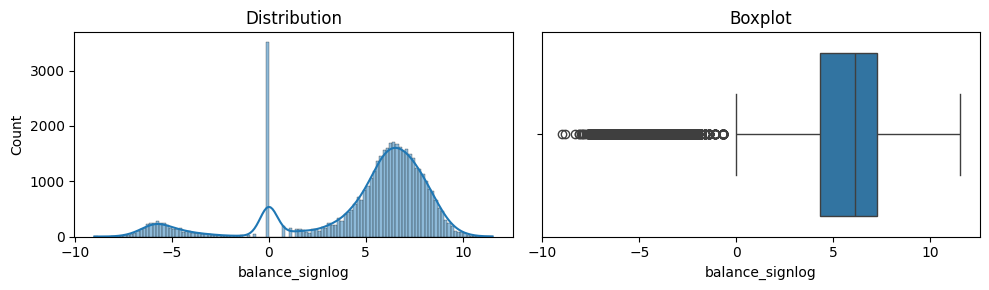

 Univariate Analysis: duration_log
Missing values: 0 (0.0%)
Unique values: 1573

Summary Statistics:
count    45211.000000
mean         5.171812
std          0.921822
min          0.000000
25%          4.644391
50%          5.198497
75%          5.768321
max          8.500861
Name: duration_log, dtype: float64
Skewness: -0.454
Kurtosis: 0.888



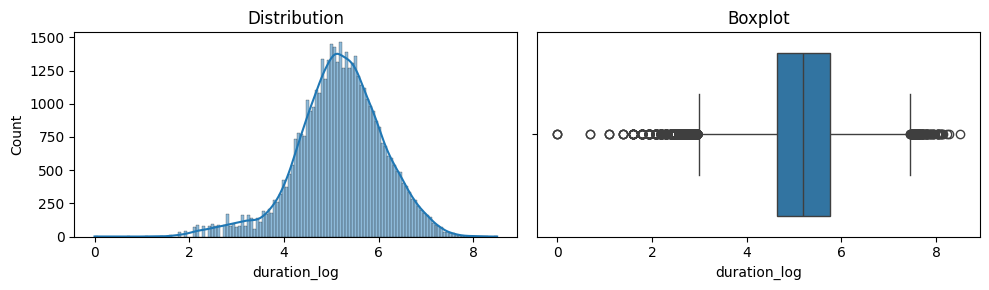

 Univariate Analysis: campaign_log
Missing values: 0 (0.0%)
Unique values: 48

Summary Statistics:
count    45211.000000
mean         1.158564
std          0.511758
min          0.693147
25%          0.693147
50%          1.098612
75%          1.386294
max          4.158883
Name: campaign_log, dtype: float64
Skewness: 1.326
Kurtosis: 2.028



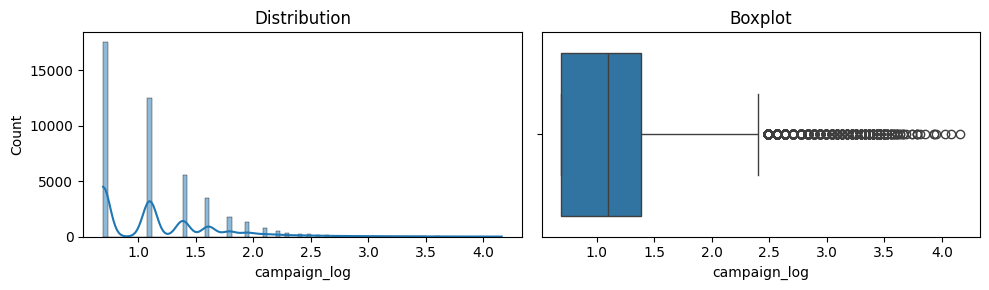

 Univariate Analysis: previous_log
Missing values: 0 (0.0%)
Unique values: 41

Summary Statistics:
count    45211.000000
mean         0.226365
std          0.533111
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.620401
Name: previous_log, dtype: float64
Skewness: 2.516
Kurtosis: 6.236



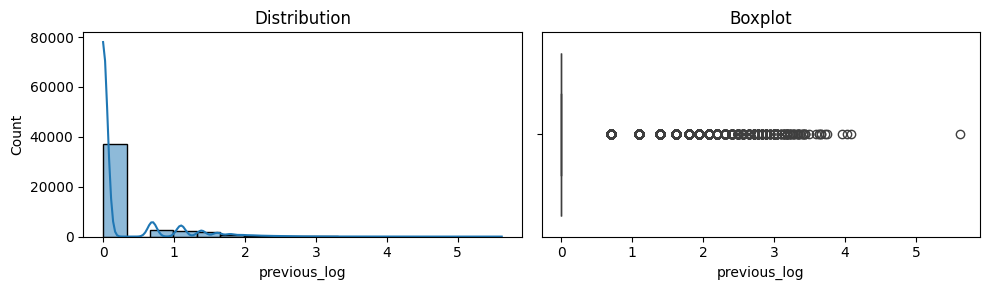

 Univariate Analysis: pdays_log
Missing values: 0 (0.0%)
Unique values: 559

Summary Statistics:
count    45211.000000
mean         0.956843
std          2.047562
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.770789
Name: pdays_log, dtype: float64
Skewness: 1.711
Kurtosis: 1.009



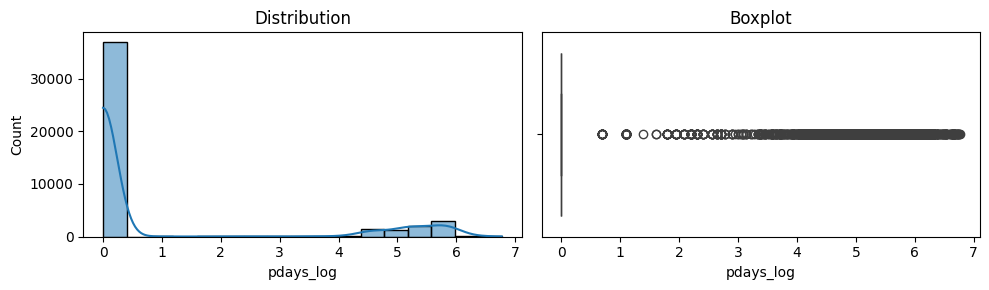

In [18]:
for col in numeric_cols:
  univariate_analysis(df, col)

| Feature                  | Distribution Shape     | Skewness          | Outlier Severity            | Business Interpretation                                      | Modeling Implication                                                     |
| ------------------------ | ---------------------- | ----------------- | --------------------------- | ------------------------------------------------------------ | ------------------------------------------------------------------------ |
| **age**                  | Slight right-skewed    | 0.685 (mild)      | Moderate high-age outliers  | Majority between 33-48 years; typical working-age population | Likely stable predictor; no strong transformation needed                 |
| **balance**              | Extremely right-skewed | 8.36 (very high)  | Severe (max = 102k)         | Most clients have low balances; few very wealthy outliers    | Log transformation required to stabilize variance                        |
| **day**                  | Approximately uniform  | 0.093 (symmetric) | None                        | Calls distributed across month days                          | Limited predictive value alone                                           |
| **duration**             | Strong right-skew      | 3.144 (high)      | Severe (max ≈ 4900 sec)     | Most calls short; few very long engagement calls             | Highly predictive but risk of leakage; log transform improves normality  |
| **campaign**             | Strong right-skew      | 4.899 (high)      | Moderate                    | Most clients contacted 1-3 times; few repeated >10 times     | Log transform improves distribution; high values may indicate resistance |
| **pdays**                | Highly zero-inflated   | 2.622 (high)      | Many zeros + long tail      | Majority never previously contacted                          | Binary “previously_contacted” feature is more informative                |
| **previous**             | Extremely skewed       | 41.846 (extreme)  | Severe long tail            | Most clients have zero previous contacts                     | Log transform reduces extreme skew; original version unstable            |
| **previously_contacted** | Binary                 | 1.643 (right)     | N/A                         | ~18% previously contacted                                    | Strong behavioral indicator                                              |
| **balance_signlog**      | Moderately left-skew   | -1.583            | Reduced                     | Distribution stabilized vs raw balance                       | Suitable for linear models                                               |
| **duration_log**         | Near normal            | -0.454            | Reduced                     | Long calls compressed                                        | Better modeling stability                                                |
| **campaign_log**         | Mild skew              | 1.326             | Reduced                     | Extreme repetition compressed                                | Improved robustness                                                      |
| **previous_log**         | Still right-skewed     | 2.516             | Reduced but still long tail | Many zeros remain                                            | May benefit from binary interaction                                      |
| **pdays_log**            | Mild right-skew        | 1.711             | Reduced                     | Still zero-heavy                                             | Keep binary + log together                                               |


**Categorical Features**

 Univariate Analysis: job
Missing values: 0 (0.0%)
Unique values: 12

Value Counts:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64



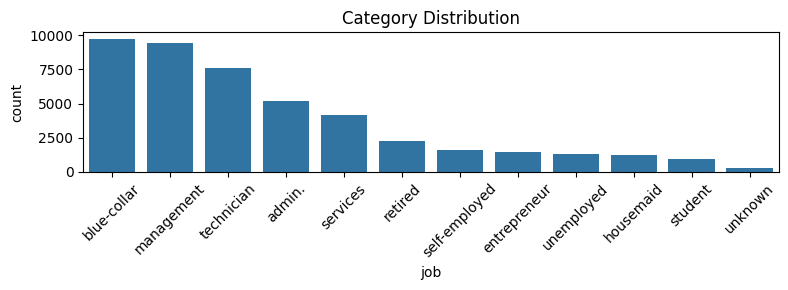

 Univariate Analysis: marital
Missing values: 0 (0.0%)
Unique values: 3

Value Counts:
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64



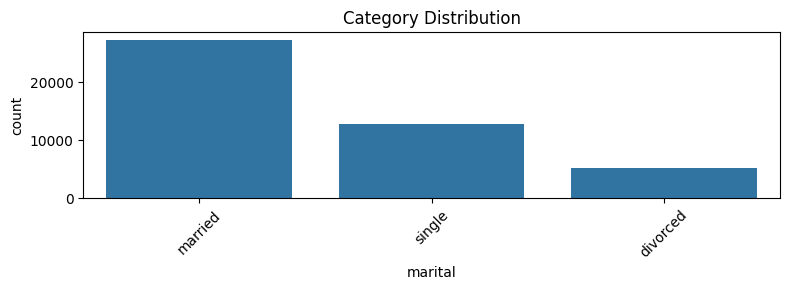

 Univariate Analysis: education
Missing values: 0 (0.0%)
Unique values: 4

Value Counts:
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64



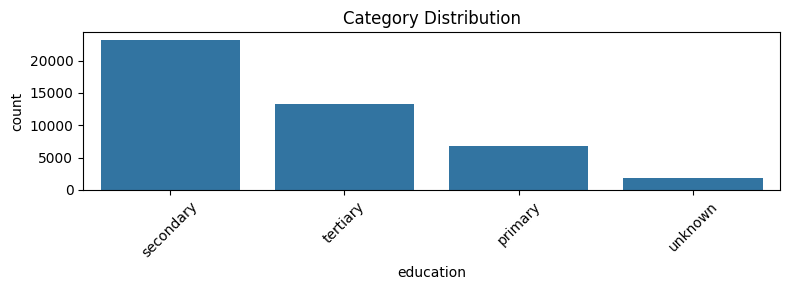

 Univariate Analysis: default
Missing values: 0 (0.0%)
Unique values: 2

Value Counts:
default
no     44396
yes      815
Name: count, dtype: int64



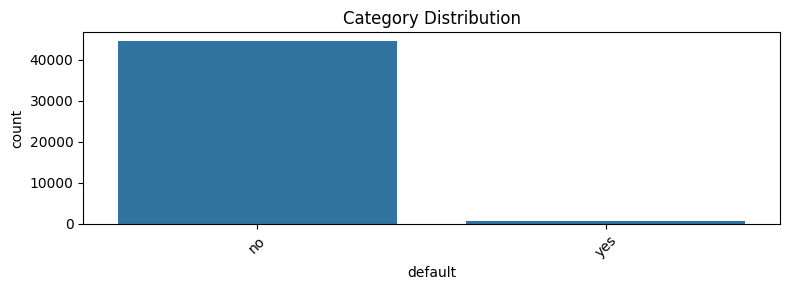

 Univariate Analysis: housing
Missing values: 0 (0.0%)
Unique values: 2

Value Counts:
housing
yes    25130
no     20081
Name: count, dtype: int64



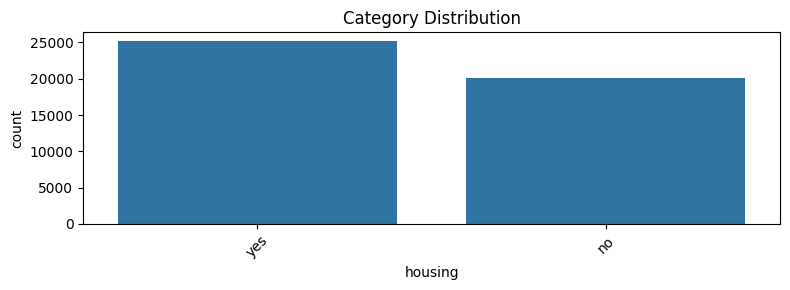

 Univariate Analysis: loan
Missing values: 0 (0.0%)
Unique values: 2

Value Counts:
loan
no     37967
yes     7244
Name: count, dtype: int64



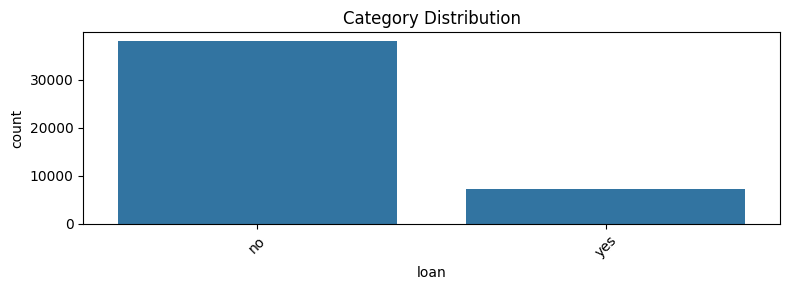

 Univariate Analysis: contact
Missing values: 0 (0.0%)
Unique values: 3

Value Counts:
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64



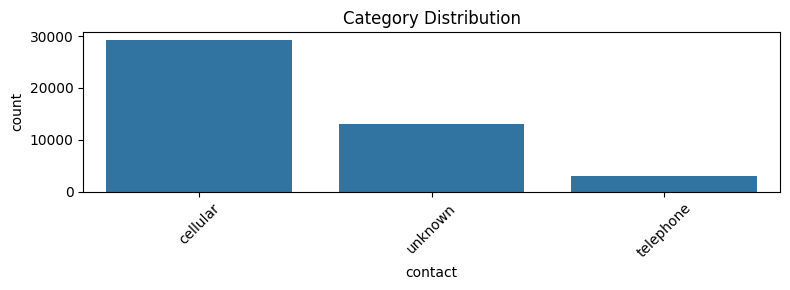

 Univariate Analysis: month
Missing values: 0 (0.0%)
Unique values: 12

Value Counts:
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64



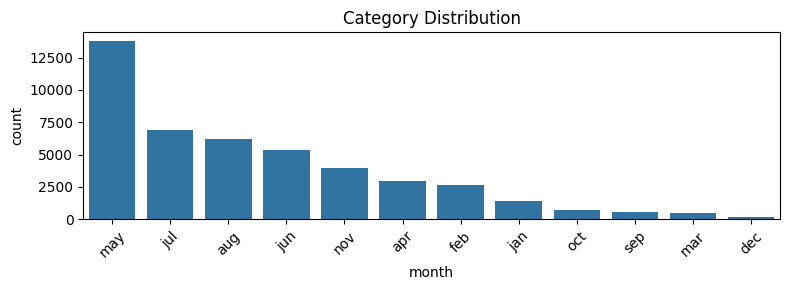

 Univariate Analysis: poutcome
Missing values: 0 (0.0%)
Unique values: 4

Value Counts:
poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64



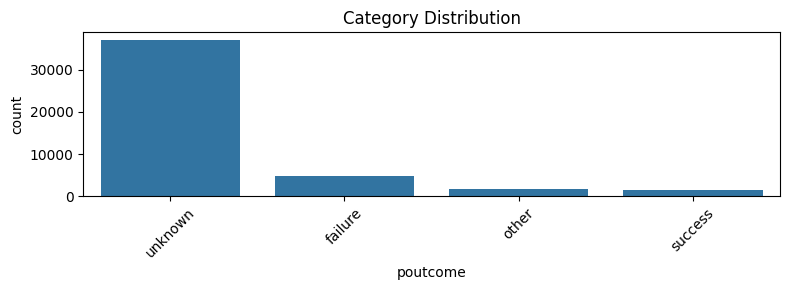

 Univariate Analysis: y
Missing values: 0 (0.0%)
Unique values: 2

Value Counts:
y
no     39922
yes     5289
Name: count, dtype: int64



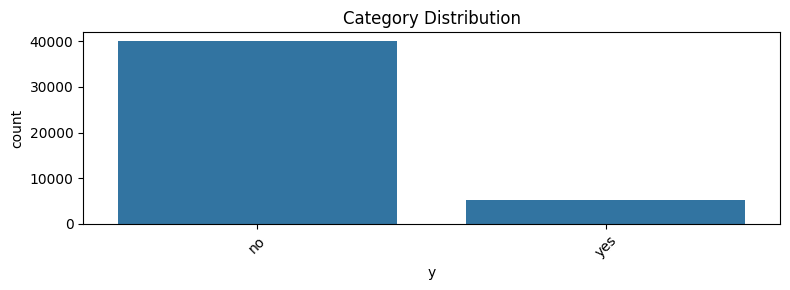

In [19]:
for col in categorical_cols:
  univariate_analysis(df, col)

| Feature        | Dominant Category       | Distribution Pattern                   | Data Quality Notes          | Business Insight                                          | Modeling Implication                                           |
| -------------- | ----------------------- | -------------------------------------- | --------------------------- | --------------------------------------------------------- | -------------------------------------------------------------- |
| **job**        | Blue-collar, Management | Concentrated in 3–4 main occupations   | Very low “unknown” (288)    | Campaign targets mostly employed individuals              | Likely predictive; manageable cardinality for one-hot encoding |
| **marital**    | Married (≈60%)          | Majority married                       | Clean distribution          | Family/financial stability may influence deposit behavior | Potential interaction with age/income                          |
| **education**  | Secondary (≈51%)        | Most have at least secondary education | Small “unknown” share       | Education may correlate with financial literacy           | Useful predictor; ordinal relationship possible                |
| **default**    | No (≈98%)               | Extremely imbalanced                   | Very few “yes”              | Dataset mostly low-risk clients                           | Low variance; may have limited predictive power                |
| **housing**    | Yes (≈56%)              | Slight majority                        | Balanced binary             | Many clients carry mortgages                              | Could influence savings behavior                               |
| **loan**       | No (≈84%)               | Majority without personal loans        | Clean binary                | Clients without loans may have higher liquidity           | Potentially meaningful feature                                 |
| **contact**    | Cellular (≈65%)         | Mobile dominates                       | High “unknown” share (≈29%) | Mobile is primary campaign channel                        | Channel effectiveness may vary                                 |
| **month**      | May dominant            | Strong seasonal concentration          | Highly uneven distribution  | Campaign heavily active in May                            | Captures seasonality; risk of campaign bias                    |
| **poutcome**   | Unknown (≈82%)          | Majority not previously contacted      | High structural imbalance   | Most clients have no prior campaign history               | Strong predictor when known                                    |
| **y (target)** | No (≈88%)               | Strongly imbalanced                    | No missing values           | Low conversion rate                                       | Requires F1-score / class weighting                            |



**Bivariate analysis (relationships)**

In [20]:
# 1) Numeric vs Numeric
def bivariate_num_num(df, x, y):
    s1, s2 = df[x], df[y]
    corr = s1.corr(s2)
    print(f"Numeric vs Numeric: {x} vs {y}")
    print(f"Pearson correlation: {corr:.4f}")

    plt.figure(figsize=(10,3))
    sns.scatterplot(x=s1, y=s2, alpha=0.5)
    plt.title(f"{x} vs {y} (corr={corr:.2f})")
    plt.tight_layout()
    plt.show()


# 2) Numeric vs Categorical
def bivariate_num_cat(df, num_col, cat_col):
    print(f"Numeric vs Categorical: {num_col} vs {cat_col}\n")
    print(df.groupby(cat_col)[num_col].describe())

    plt.figure(figsize=(10,3))
    sns.boxplot(x=df[num_col], y=df[cat_col])
    plt.title(f"{num_col} by {cat_col}")
    plt.tight_layout()
    plt.show()

# 3) Categorical vs Categorical
def bivariate_cat_cat(df, col1, col2, normalize=False):
    ct = pd.crosstab(df[col1], df[col2], normalize="index" if normalize else False)
    print(f"Categorical vs Categorical: {col1} vs {col2}\n")
    print(ct)

    # Chi-square only makes sense on raw counts
    ct_counts = pd.crosstab(df[col1], df[col2])
    chi2, p, _, _ = chi2_contingency(ct_counts)
    print(f"\nChi-square p-value: {p:.4f}")

    plt.figure(figsize=(10,4))
    sns.heatmap(ct_counts, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Crosstab: {col1} vs {col2}")
    plt.tight_layout()
    plt.show()

**Numeric vs Numeric Features**

Numeric vs Numeric: age vs balance
Pearson correlation: 0.0978


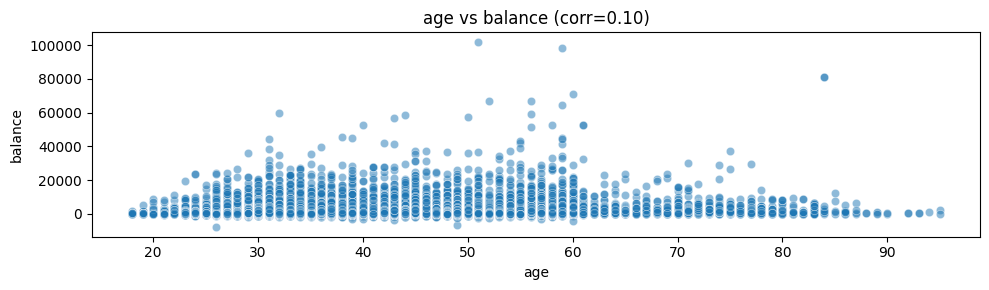

In [21]:
bivariate_num_num(df, "age", "balance")

Numeric vs Numeric: age vs duration
Pearson correlation: -0.0046


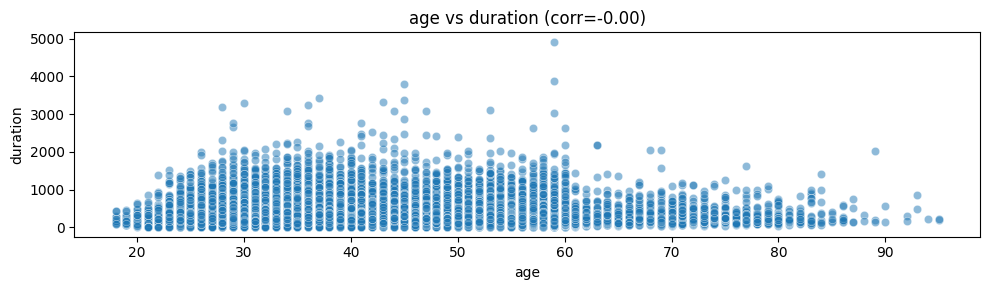

In [22]:
bivariate_num_num(df, "age", "duration")

Numeric vs Numeric: balance vs duration
Pearson correlation: 0.0216


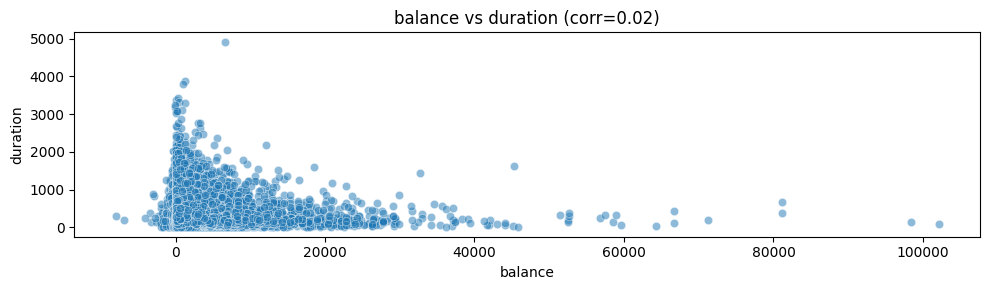

In [23]:
bivariate_num_num(df, "balance", "duration")

Numeric vs Numeric: campaign vs previous
Pearson correlation: -0.0329


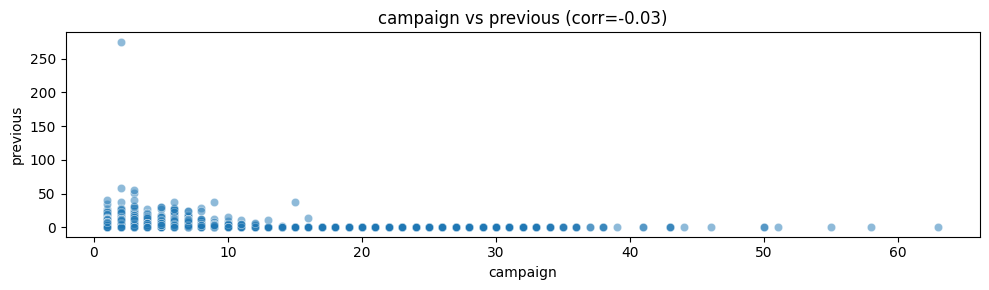

In [24]:
bivariate_num_num(df, "campaign", "previous")

Numeric vs Numeric: campaign vs pdays
Pearson correlation: -0.0885


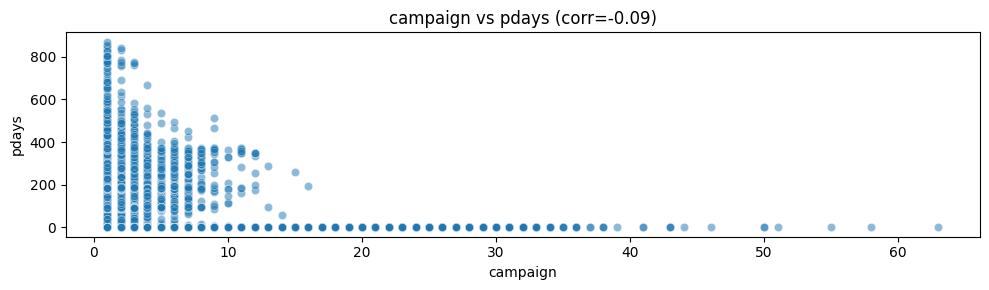

In [25]:
bivariate_num_num(df, "campaign", "pdays")

**Numeric vs Numeric Features (Transformed)**



Numeric vs Numeric: balance_signlog vs duration_log
Pearson correlation: 0.0302


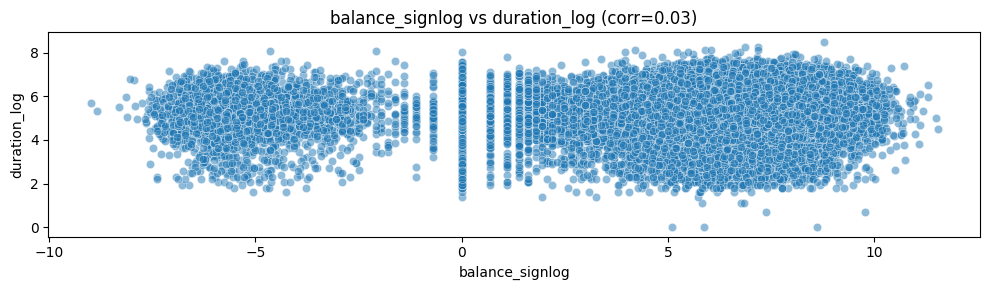

In [26]:
bivariate_num_num(df, "balance_signlog", "duration_log")

Numeric vs Numeric: balance_signlog vs campaign_log
Pearson correlation: -0.0335


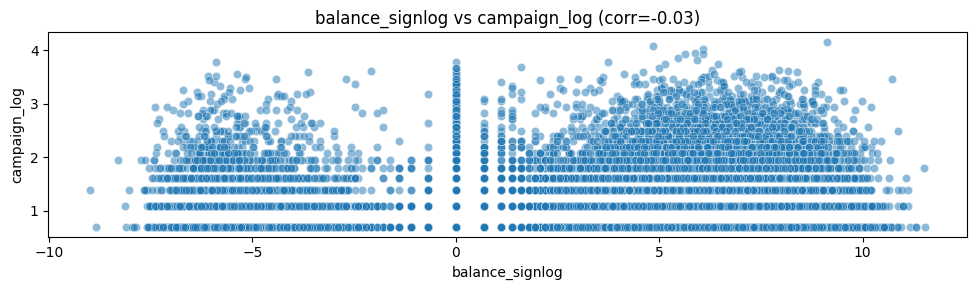

In [27]:
bivariate_num_num(df, "balance_signlog", "campaign_log")

Numeric vs Numeric: duration_log vs campaign_log
Pearson correlation: -0.1828


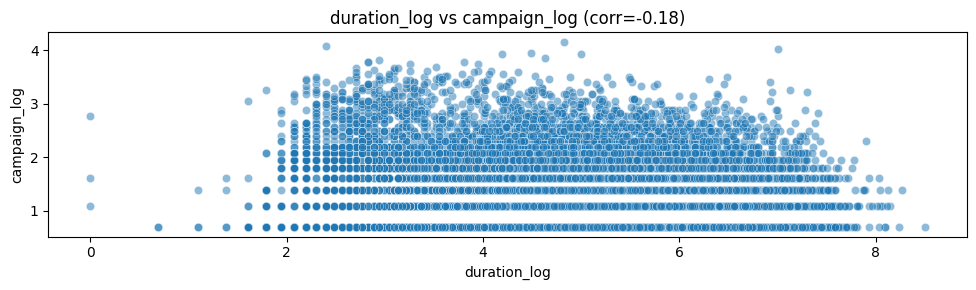

In [28]:
bivariate_num_num(df, "duration_log", "campaign_log")

Numeric vs Numeric: previous_log vs campaign_log
Pearson correlation: -0.0830


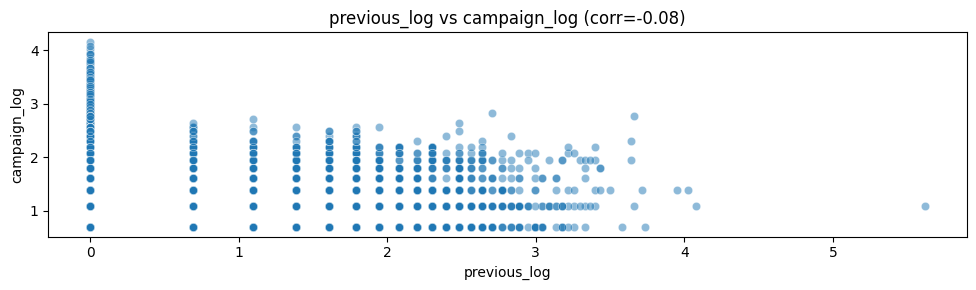

In [29]:
bivariate_num_num(df, "previous_log", "campaign_log")

Numeric vs Numeric: pdays_log vs previous_log
Pearson correlation: 0.8841


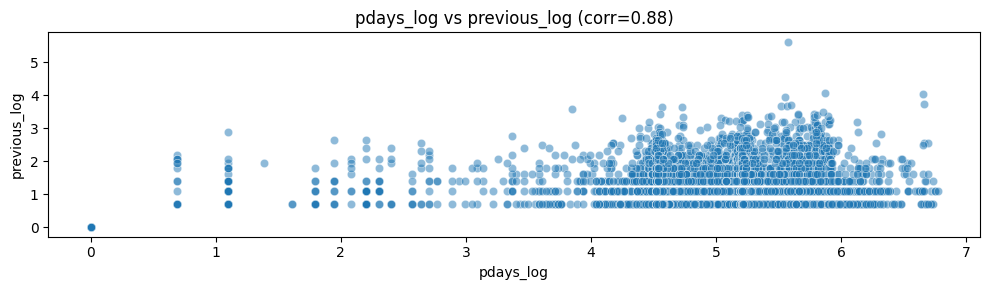

In [30]:
bivariate_num_num(df, "pdays_log", "previous_log")

**Numeric Features vs Target (y)**

Numeric vs Categorical: age vs y

       count       mean        std   min   25%   50%   75%   max
y                                                               
no   39922.0  40.838986  10.172662  18.0  33.0  39.0  48.0  95.0
yes   5289.0  41.670070  13.497781  18.0  31.0  38.0  50.0  95.0


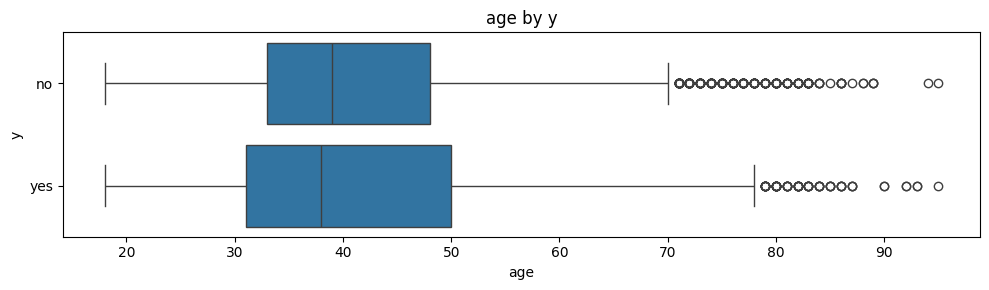

In [31]:
bivariate_num_cat(df, "age", "y")

Numeric vs Categorical: balance_signlog vs y

       count      mean       std       min       25%       50%       75%  \
y                                                                          
no   39922.0  4.761268  3.875878 -8.989694  4.077537  6.035481  7.204893   
yes   5289.0  5.836943  3.085788 -8.025843  5.351858  6.598509  7.677864   

           max  
y               
no   11.533982  
yes  11.304732  


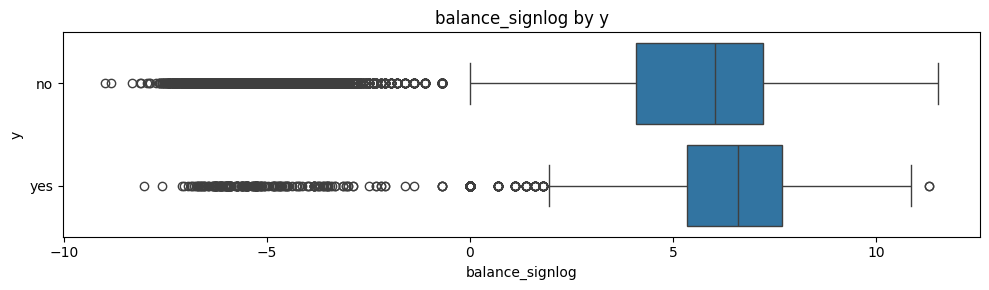

In [32]:
bivariate_num_cat(df, "balance_signlog", "y")

Numeric vs Categorical: duration_log vs y

       count      mean       std       min       25%       50%      75%  \
y                                                                         
no   39922.0  5.056804  0.883138  0.000000  4.564348  5.105945  5.63479   
yes   5289.0  6.039907  0.723497  2.197225  5.501258  6.056784  6.58755   

          max  
y              
no   8.500861  
yes  8.264106  


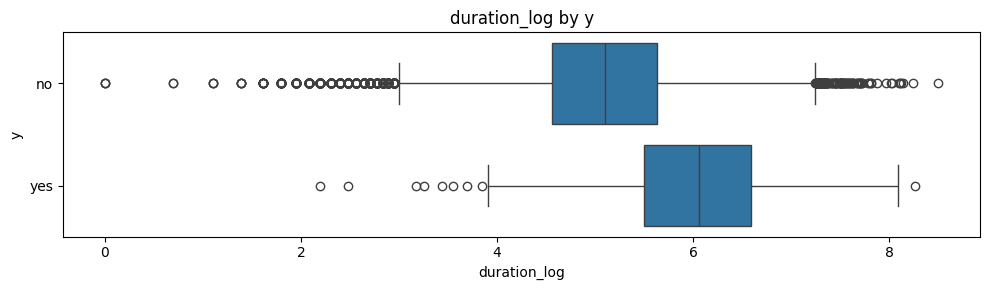

In [33]:
bivariate_num_cat(df, "duration_log", "y")

Numeric vs Categorical: campaign_log vs y

       count      mean       std       min       25%       50%       75%  \
y                                                                          
no   39922.0  1.174628  0.520677  0.693147  0.693147  1.098612  1.386294   
yes   5289.0  1.037306  0.419257  0.693147  0.693147  1.098612  1.386294   

          max  
y              
no   4.158883  
yes  3.496508  


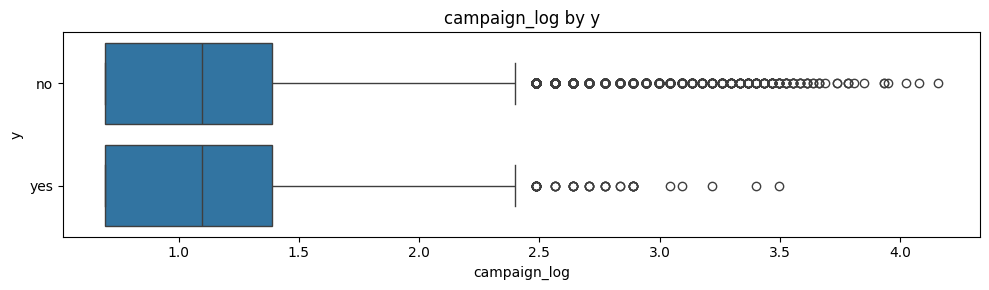

In [34]:
bivariate_num_cat(df, "campaign_log", "y")

Numeric vs Categorical: previous_log vs y

       count      mean       std  min  25%  50%       75%       max
y                                                                  
no   39922.0  0.195484  0.500147  0.0  0.0  0.0  0.000000  5.620401
yes   5289.0  0.459461  0.692710  0.0  0.0  0.0  0.693147  4.077537


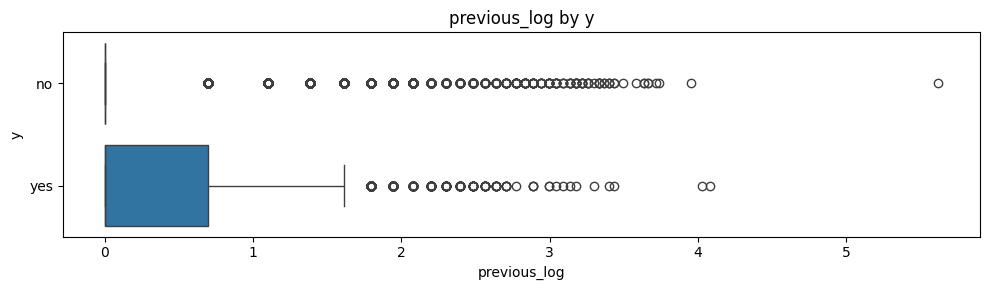

In [35]:
bivariate_num_cat(df, "previous_log", "y")

Numeric vs Categorical: pdays_log vs y

       count      mean       std  min  25%  50%      75%       max
y                                                                 
no   39922.0  0.841750  1.956594  0.0  0.0  0.0  0.00000  6.770789
yes   5289.0  1.825582  2.467447  0.0  0.0  0.0  4.59512  6.751101


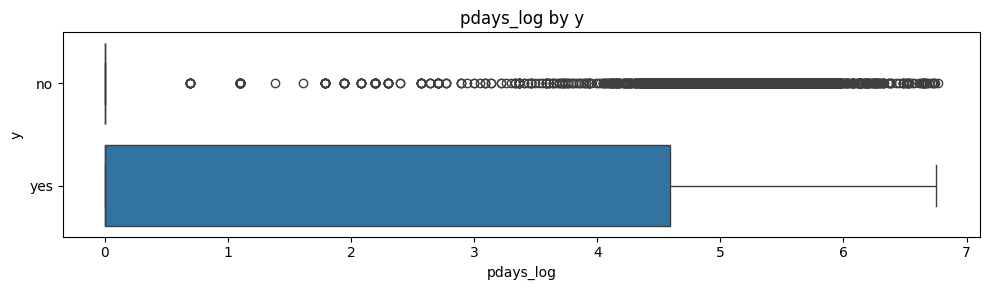

In [36]:
bivariate_num_cat(df, "pdays_log", "y")

**Numeric vs Other Categorical**

Numeric vs Categorical: balance_signlog vs job

                count      mean       std       min       25%       50%  \
job                                                                       
admin.         5171.0  4.677838  3.896165 -7.379008  4.158883  5.983936   
blue-collar    9732.0  4.540910  4.055499 -8.989694  4.025352  5.963579   
entrepreneur   1487.0  4.742814  3.800608 -7.641564  3.817652  5.866468   
housemaid      1240.0  5.123264  3.200941 -7.571474  4.073264  6.008786   
management     9458.0  5.263008  3.611808 -8.831712  4.595120  6.350886   
retired        2264.0  5.612334  3.458562 -7.377134  5.108957  6.669495   
self-employed  1579.0  5.280423  3.469658 -8.105911  4.795791  6.267201   
services       4154.0  4.345950  4.105258 -7.660585  3.583519  5.830414   
student         938.0  5.836873  2.396135 -6.522093  5.005619  6.220590   
technician     7597.0  4.781649  3.861968 -7.947325  4.127134  6.045005   
unemployed     1303.0  5.235471  3.452770 -7.147559 

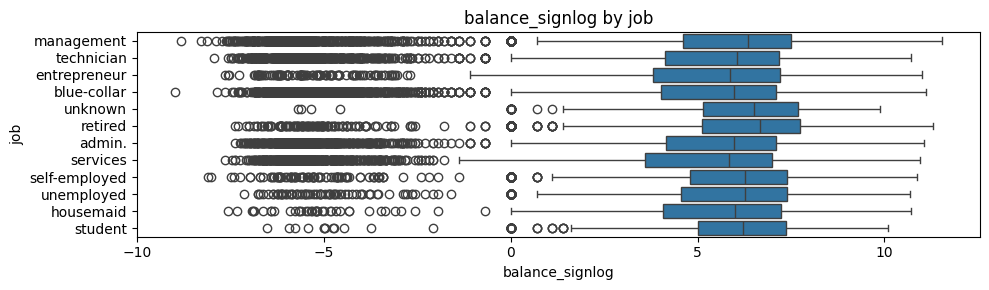

In [37]:
bivariate_num_cat(df, "balance_signlog", "job")

Numeric vs Categorical: balance_signlog vs marital

            count      mean       std       min       25%       50%       75%  \
marital                                                                         
divorced   5207.0  4.376664  4.116745 -8.308446  3.258097  5.855072  7.095477   
married   27214.0  4.928068  3.824143 -8.831712  4.330733  6.169611  7.323831   
single    12790.0  5.007757  3.620998 -8.989694  4.510860  6.082219  7.197997   

                max  
marital              
divorced  11.108290  
married   11.496979  
single    11.533982  


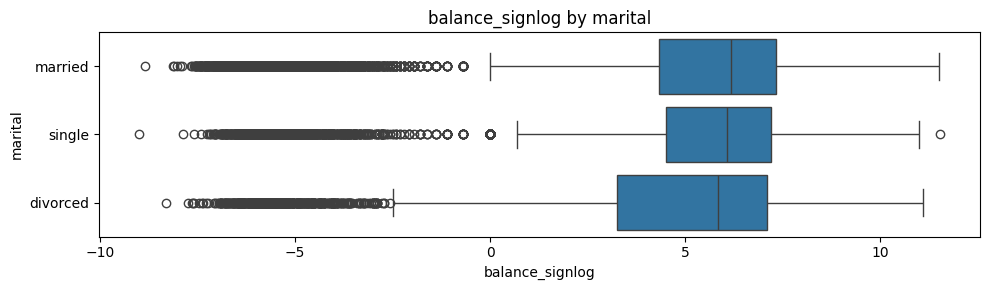

In [38]:
bivariate_num_cat(df, "balance_signlog", "marital")

Numeric vs Categorical: duration_log vs education

             count      mean       std       min       25%       50%  \
education                                                              
primary     6851.0  5.148144  0.944180  0.000000  4.644391  5.187386   
secondary  23202.0  5.181949  0.916470  0.000000  4.663439  5.214936   
tertiary   13301.0  5.168412  0.914544  1.098612  4.624973  5.176150   
unknown     1857.0  5.156827  0.955119  1.609438  4.605170  5.198497   

                75%       max  
education                      
primary    5.746203  8.032360  
secondary  5.774552  8.264106  
tertiary   5.765191  8.500861  
unknown    5.808142  7.795647  


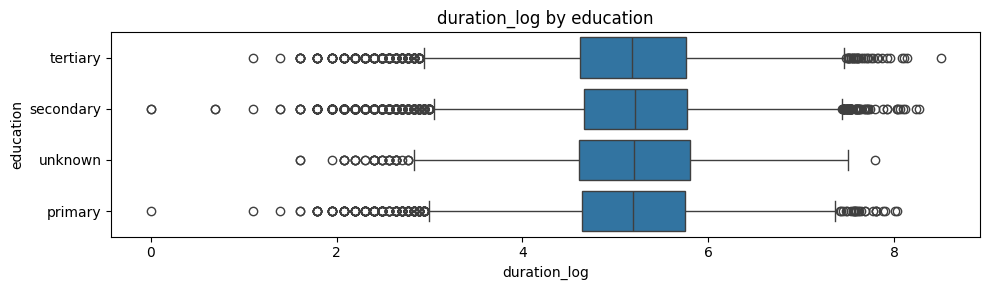

In [39]:
bivariate_num_cat(df, "duration_log", "education")

Numeric vs Categorical: age vs housing

           count       mean        std   min   25%   50%   75%   max
housing                                                             
no       20081.0  43.139883  12.058696  18.0  33.0  42.0  52.0  95.0
yes      25130.0  39.175288   8.926807  20.0  32.0  38.0  45.0  78.0


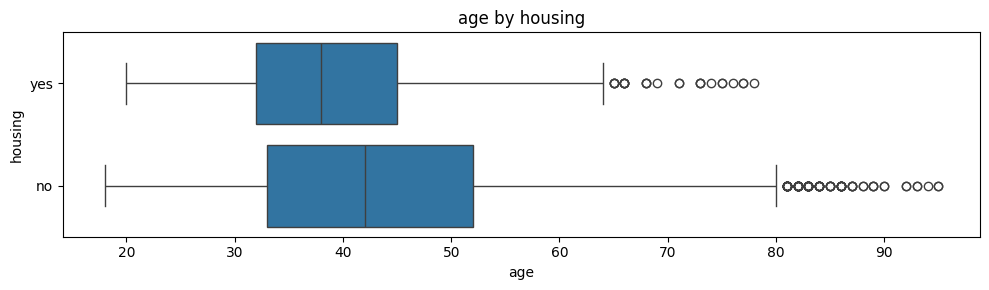

In [40]:
bivariate_num_cat(df, "age", "housing")

Numeric vs Categorical: campaign_log vs loan

        count      mean       std       min       25%       50%       75%  \
loan                                                                        
no    37967.0  1.157366  0.509080  0.693147  0.693147  1.098612  1.386294   
yes    7244.0  1.164843  0.525561  0.693147  0.693147  1.098612  1.386294   

           max  
loan            
no    4.158883  
yes   3.931826  


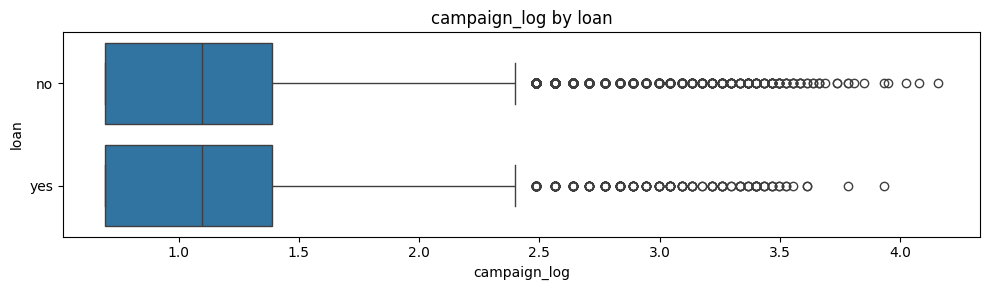

In [41]:
bivariate_num_cat(df, "campaign_log", "loan")

**Categorical vs Categorical Features**

Categorical vs Categorical: job vs education

education      primary  secondary  tertiary  unknown
job                                                 
admin.             209       4219       572      171
blue-collar       3758       5371       149      454
entrepreneur       183        542       686       76
housemaid          627        395       173       45
management         294       1121      7801      242
retired            795        984       366      119
self-employed      130        577       833       39
services           345       3457       202      150
student             44        508       223      163
technician         158       5229      1968      242
unemployed         257        728       289       29
unknown             51         71        39      127

Chi-square p-value: 0.0000


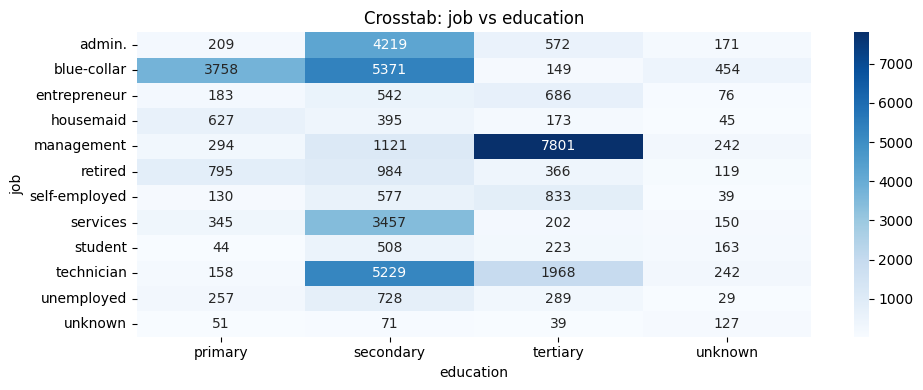

In [42]:
bivariate_cat_cat(df, "job", "education")

Categorical vs Categorical: marital vs housing

housing      no    yes
marital               
divorced   2300   2907
married   11893  15321
single     5888   6902

Chi-square p-value: 0.0001


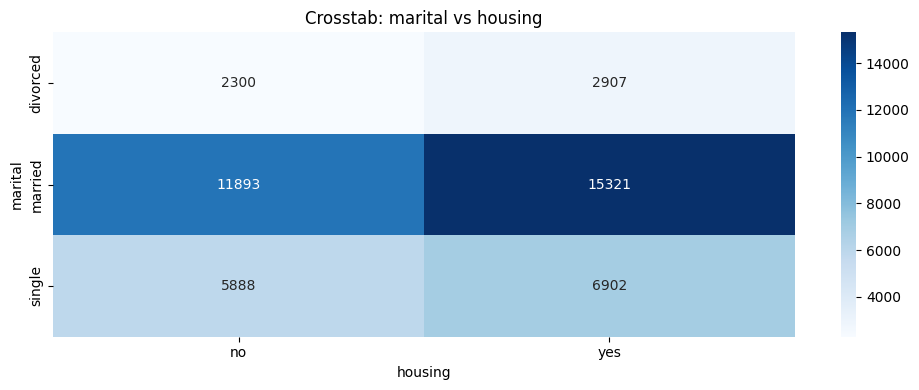

In [43]:
bivariate_cat_cat(df, "marital", "housing")

Categorical vs Categorical: loan vs housing

housing     no    yes
loan                 
no       17204  20763
yes       2877   4367

Chi-square p-value: 0.0000


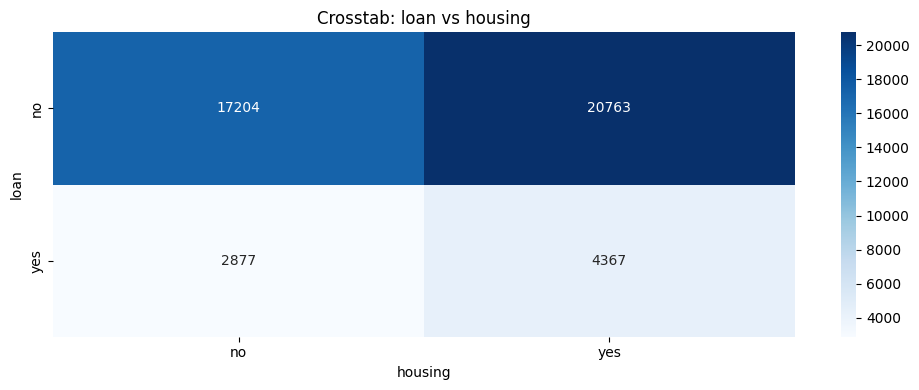

In [44]:
bivariate_cat_cat(df, "loan", "housing")

Categorical vs Categorical: contact vs month

month       apr   aug  dec   feb   jan   jul   jun  mar   may   nov  oct  sep
contact                                                                      
cellular   2727  5950  174  2362  1265  5767   729  417  5331  3540  557  466
telephone   199   246   37   274   129   852    80   53   460   379  131   66
unknown       6    51    3    13     9   276  4532    7  7975    51   50   47

Chi-square p-value: 0.0000


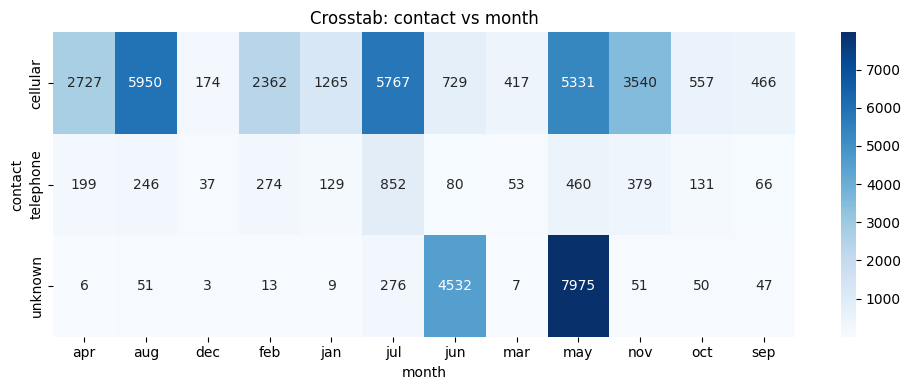

In [45]:
bivariate_cat_cat(df, "contact", "month")

**Categorical Features vs Target (y)**

Categorical vs Categorical: job vs y

y                    no       yes
job                              
admin.         0.877973  0.122027
blue-collar    0.927250  0.072750
entrepreneur   0.917283  0.082717
housemaid      0.912097  0.087903
management     0.862444  0.137556
retired        0.772085  0.227915
self-employed  0.881571  0.118429
services       0.911170  0.088830
student        0.713220  0.286780
technician     0.889430  0.110570
unemployed     0.844973  0.155027
unknown        0.881944  0.118056

Chi-square p-value: 0.0000


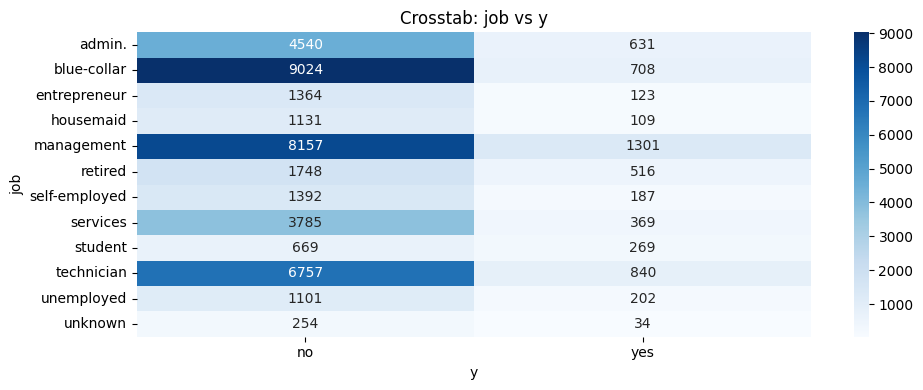

In [46]:
bivariate_cat_cat(df, "job", "y", normalize=True)

Categorical vs Categorical: marital vs y

y               no       yes
marital                     
divorced  0.880545  0.119455
married   0.898765  0.101235
single    0.850508  0.149492

Chi-square p-value: 0.0000


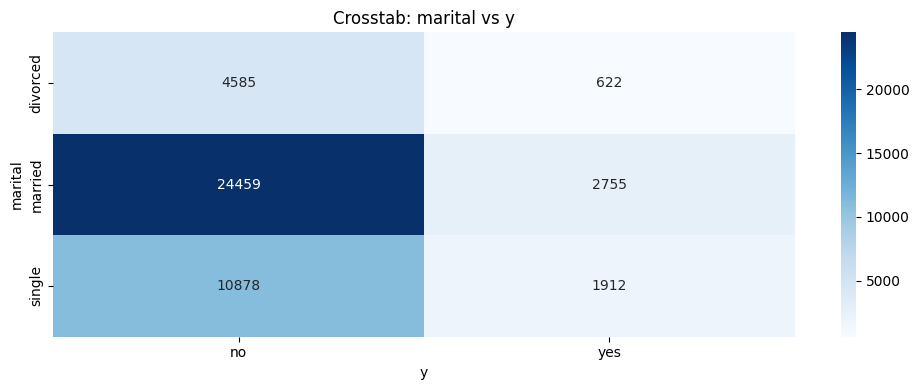

In [47]:
bivariate_cat_cat(df, "marital", "y", normalize=True)

Categorical vs Categorical: education vs y

y                no       yes
education                    
primary    0.913735  0.086265
secondary  0.894406  0.105594
tertiary   0.849936  0.150064
unknown    0.864297  0.135703

Chi-square p-value: 0.0000


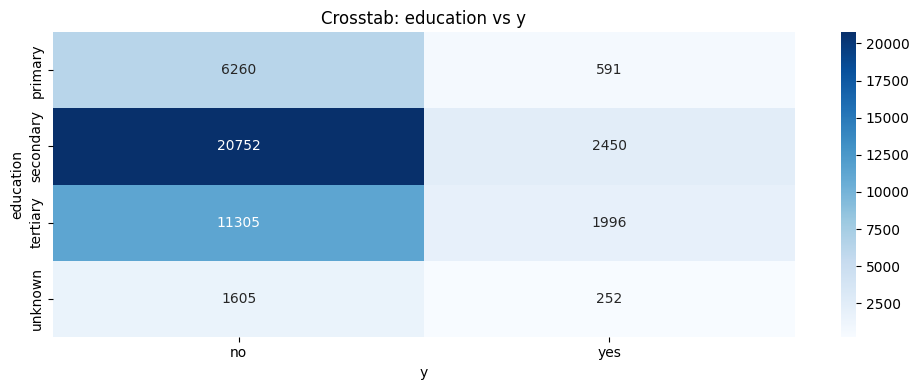

In [48]:
bivariate_cat_cat(df, "education", "y", normalize=True)

Categorical vs Categorical: housing vs y

y              no       yes
housing                    
no       0.832976  0.167024
yes      0.923000  0.077000

Chi-square p-value: 0.0000


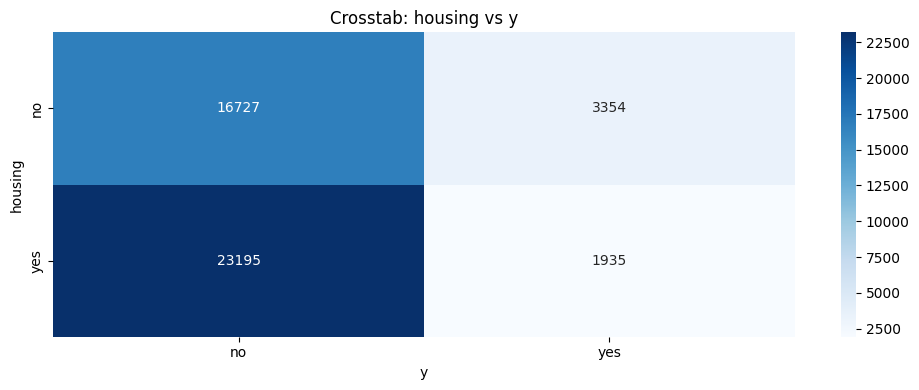

In [49]:
bivariate_cat_cat(df, "housing", "y", normalize=True)

Categorical vs Categorical: loan vs y

y           no       yes
loan                    
no    0.873443  0.126557
yes   0.933186  0.066814

Chi-square p-value: 0.0000


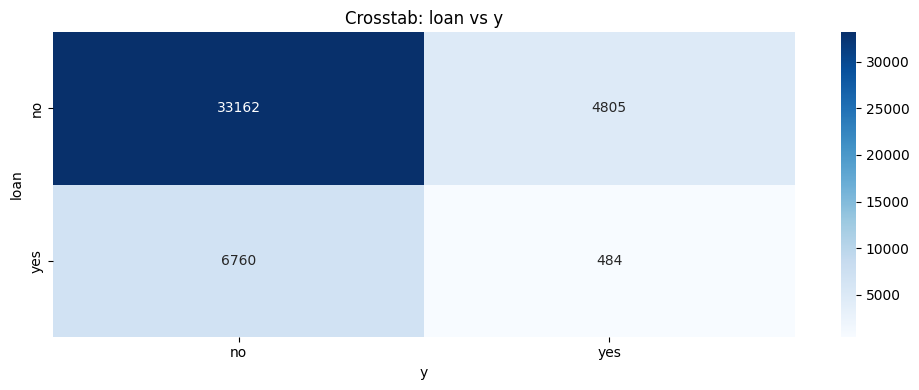

In [50]:
bivariate_cat_cat(df, "loan", "y", normalize=True)

Categorical vs Categorical: contact vs y

y                no       yes
contact                      
cellular   0.850811  0.149189
telephone  0.865795  0.134205
unknown    0.959293  0.040707

Chi-square p-value: 0.0000


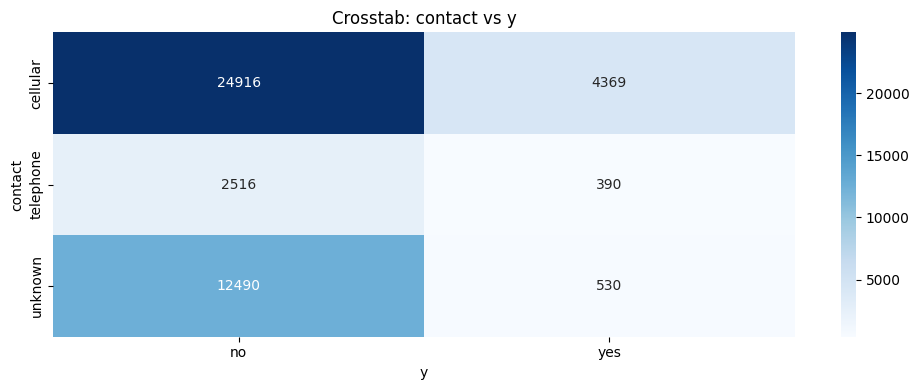

In [51]:
bivariate_cat_cat(df, "contact", "y", normalize=True)

Categorical vs Categorical: month vs y

y            no       yes
month                    
apr    0.803206  0.196794
aug    0.889867  0.110133
dec    0.532710  0.467290
feb    0.833522  0.166478
jan    0.898788  0.101212
jul    0.909065  0.090935
jun    0.897772  0.102228
mar    0.480084  0.519916
may    0.932805  0.067195
nov    0.898489  0.101511
oct    0.562331  0.437669
sep    0.535406  0.464594

Chi-square p-value: 0.0000


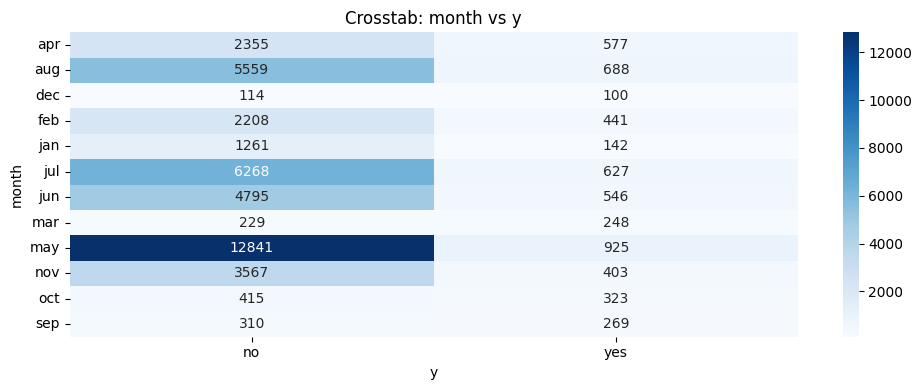

In [52]:
bivariate_cat_cat(df, "month", "y", normalize=True)

Categorical vs Categorical: poutcome vs y

y               no       yes
poutcome                    
failure   0.873903  0.126097
other     0.833152  0.166848
success   0.352747  0.647253
unknown   0.908385  0.091615

Chi-square p-value: 0.0000


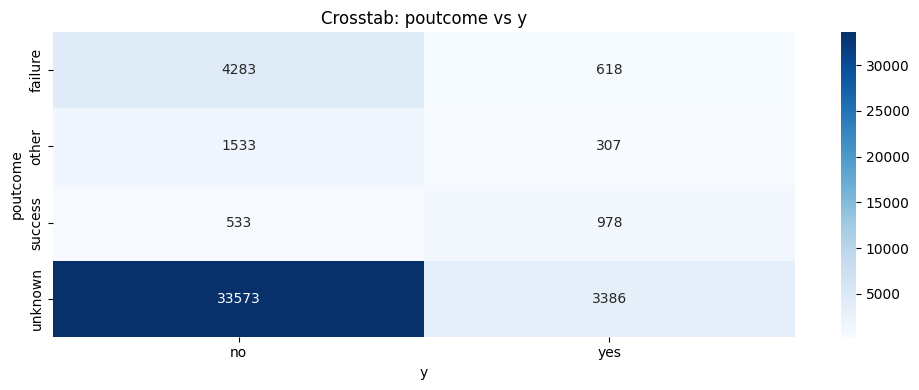

In [53]:
bivariate_cat_cat(df, "poutcome", "y", normalize=True)

Categorical vs Categorical: previously_contacted vs y

y                           no       yes
previously_contacted                    
0                     0.908427  0.091573
1                     0.769287  0.230713

Chi-square p-value: 0.0000


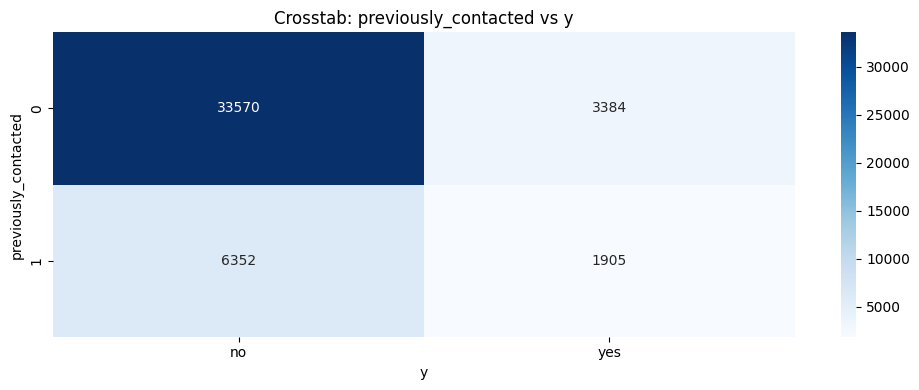

In [54]:
bivariate_cat_cat(df, "previously_contacted", "y", normalize=True)

**Correlation Analysis**

In [55]:
def correlation_analysis(df, method="pearson", target=None, figsize=(10,8),
                         annot=False, fmt=".2f", cmap="Blues",
                         target_map=None):
    """
    method: 'pearson', 'spearman', or 'kendall'
    target: optional target column name (can be categorical)
    target_map: optional dict for encoding target, e.g. {'no':0,'yes':1}
    """

    # Correlation matrix for numeric columns only
    numeric_df = df.select_dtypes(include="number")
    if numeric_df.shape[1] == 0:
        print("No numeric columns found for correlation heatmap.")
        corr_matrix = None
    else:
        corr_matrix = numeric_df.corr(method=method)

        plt.figure(figsize=figsize)
        sns.heatmap(
            corr_matrix,
            cmap=cmap,
            annot=annot,
            fmt=fmt,
            linewidths=0.5,
            square=True
        )
        plt.title(f"{method.title()} Correlation Heatmap (Numeric Features)")
        plt.tight_layout()
        plt.show()

    # target correlation ranking
    if target is not None:
        if target not in df.columns:
            print(f"Target '{target}' not found.")
            return corr_matrix

        y = df[target]

        # Encode target if not numeric
        if not pd.api.types.is_numeric_dtype(y):
            if target_map is None:
                default_map = {"no": 0, "yes": 1}
                if set(y.dropna().unique()).issubset(set(default_map.keys())):
                    y_enc = y.map(default_map)
                else:
                    y_enc = pd.Series(pd.factorize(y)[0], index=df.index)
            else:
                y_enc = y.map(target_map)
        else:
            y_enc = y.astype(float)

        # correlate target against numeric features (including engineered numeric cols)
        num_cols = df.select_dtypes(include="number").columns
        target_corr = df[num_cols].corrwith(y_enc, method=method).dropna().sort_values(key=abs, ascending=False)

        print("\n" + "="*150)
        print(f"{method.title()} correlation with target: {target} (encoded)")
        print("="*150)
        print(target_corr)

        return corr_matrix, target_corr

    return corr_matrix

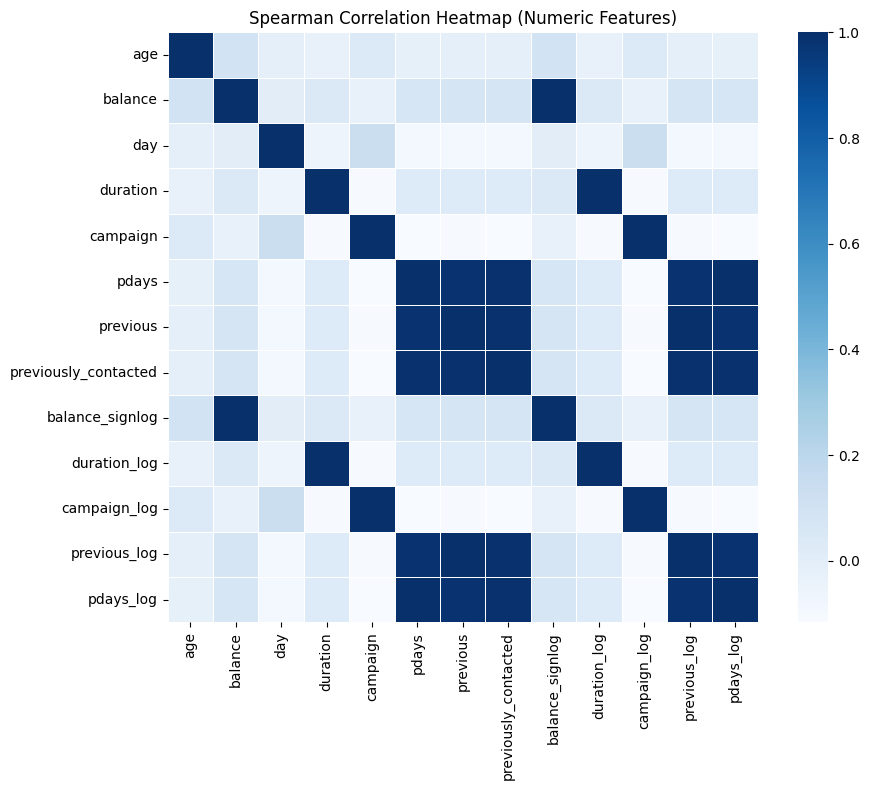


Spearman correlation with target: y (encoded)
duration                0.342469
duration_log            0.342469
previous                0.169124
previous_log            0.169124
previously_contacted    0.167263
pdays_log               0.154055
pdays                   0.154055
balance_signlog         0.100295
balance                 0.100295
campaign               -0.084054
campaign_log           -0.084054
day                    -0.029548
age                    -0.008750
dtype: float64


In [56]:
correlationmatrix = correlation_analysis(df, method="spearman", target="y")

**Structural Redundancy**
| Feature A | Feature B       | Interpretation                 | Modeling Action |
| --------- | --------------- | ------------------------------ | --------------- |
| duration  | duration_log    | Log transform of same variable | Keep only one   |
| campaign  | campaign_log    | Log transform                  | Keep only one   |
| balance   | balance_signlog | Signed log transform           | Keep only one   |
| previous  | previous_log    | Log transform                  | Keep only one   |
| pdays     | pdays_log       | Log transform                  | Keep only one   |

**Note:** Consider only one version in the same model.



**Previous-Countact Structural Cluster**
| Variable             | Meaning                 | Why Highly Correlated           |
| -------------------- | ----------------------- | ------------------------------- |
| previous             | number of past contacts         | Non-zero → previously contacted |                |
| pdays                | Days since last contact | Positive → previously contacted |                |
| previously_contacted | Binary contact flag     | Derived from pdays/previous     |                |
| previous_log         | Log transform           | Monotonic transform             |                |
| pdays_log            | Log transform           | Monotonic transform             |                |

**Note:** Customer Relationship History. Only keep `previously_contacted`and either `pdays_log`or `previous_log`. Drop the rest.



**Weak-to-Moderate Cross-Feature Relationships**
| Relationship        | Strength      | Interpretation                        | Concern? |
| ------------------- | ------------- | ------------------------------------- | -------- |
| balance vs age       | Weak positive | Older clients slightly higher balance | No       |
| campaignvs duration | Weak positive | More attempts → longer conversations  | No       |
| age vs others        | Very weak     | Minimal structural dependency         | No       |


In [57]:
# Final Feauture Set (Numeric + Categorical)
numeric_features = [
    "age",
    "balance_signlog",
    "campaign_log",
    "previously_contacted",
    "pdays_log",
    "day"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]
features = numeric_features + categorical_features

### 3c. Feature Engineering
- [Scaling](#scrollTo=wJlpdOGx0PGZ&line=1&uniqifier=1)
  - [Robust Scaler](#scrollTo=jiJWyLr9Adf2&line=1&uniqifier=1)
  - [Resampling (SMOTE)](#scrollTo=HmKgnlzSAQYP&line=1&uniqifier=1)
- [Encoding](#scrollTo=QzqzX65D25nQ&line=1&uniqifier=1)
  - [One Hot Encoding](#scrollTo=ozXiio3-thFn&line=1&uniqifier=1)

In [58]:
# Assign features and target value to X and y
X = df[features]
y = df["y"].map({"no": 0, "yes": 1}) if df["y"].dtype == "object" else df["y"]

# Data is highly imbalanced, stratify splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

continuous_num = ["age", "balance_signlog", "campaign_log", "pdays_log", "day"]
binary_num = ["previously_contacted"]
cat_cols = categorical_features

**Scaling**

**Robust Scaling**

In [59]:
# Robust scale numeric columns (fit on train only)
pre_smote = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), continuous_num),
        ("bin", "passthrough", binary_num),
        ("cat", "passthrough", cat_cols),
    ],
    remainder="drop"
)

# Fit preprocess on train and test
X_train_sm = pre_smote.fit_transform(X_train)
X_test_sm  = pre_smote.transform(X_test)

cat_start = len(continuous_num) + len(binary_num)
cat_indices = list(range(cat_start, cat_start + len(cat_cols)))

**Resampling using SMOTENC**


In [60]:
# Use Resampling (SMOTENC)
smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train_res, y_train_res = smote_nc.fit_resample(X_train_sm, y_train)


**Encoding**

**One Hot Encoding**

In [61]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_ohe = ohe.fit_transform(X_train_res[:, cat_start:])
X_test_cat_ohe  = ohe.transform(X_test_sm[:, cat_start:])

In [62]:
X_train_num_bin = X_train_res[:, :cat_start]
X_test_num_bin  = X_test_sm[:, :cat_start]

In [63]:
X_train_final = np.hstack([X_train_num_bin, X_train_cat_ohe])
X_test_final  = np.hstack([X_test_num_bin,  X_test_cat_ohe])

In [64]:
print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_train_res).value_counts())
print("Train shape:", X_train_final.shape, " Test shape:", X_test_final.shape)

Before SMOTE:
 y
0    31937
1     4231
Name: count, dtype: int64
After SMOTE:
 y
0    31937
1    31937
Name: count, dtype: int64
Train shape: (63874, 50)  Test shape: (9043, 50)


### 3d. Feature Selection

Embedded methods
Embedded feature selection integrates variable selection directly into the model training process.



### 3e. Dimensionality Reduction

**Principal Component Analysis**

In [65]:
pca = PCA(n_components=0.95)  # retain 95% variance

X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

print("Original features:", X_train_final.shape[1])
print("Reduced features:", X_train_pca.shape[1])

Original features: 50
Reduced features: 21


## Step 4: **Model Implementation**


In [66]:
def plot_cm_and_roc(y_true, y_pred, y_proba, model_name="Model"):
    # Compute metrics
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)

    # Create figure with 2 subplots
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{model_name} Performance", fontsize=14, fontweight="bold")

    # --- Confusion Matrix ---
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title("Confusion Matrix")
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Actual")

    # --- ROC Curve ---
    ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='orange')
    ax[1].plot([0, 1], [0, 1], 'k--', label="Random Guess")
    ax[1].set_title("ROC Curve")
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].legend(loc="lower right")
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))
    print(f"ROC-AUC: {roc_auc:.4f}")

#### 4a. Baseline Models
- [Logistic Regression](#scrollTo=RaniqqxI23Jh&line=1&uniqifier=1)
- [Logistic Regression PCA 95%](#scrollTo=-4L--a5IUAr1&line=1&uniqifier=1)
- [Decision Tree Classifier](#scrollTo=kP7f7fGyL_g8&line=1&uniqifier=1)
- [Random Forest Classifier](#scrollTo=8GCwYnpHVkG3&line=1&uniqifier=1)
- [Naive Bayes](#scrollTo=BjKYZfIDV9Fh&line=1&uniqifier=1)
- [XGBoost Classifier](#scrollTo=-iTWVUfyWvJy&line=1&uniqifier=1)


In [67]:
def save_best_model(grid_search, filename, add_timestamp=False):
    model_dir = "/content/drive/MyDrive/models"
    os.makedirs(model_dir, exist_ok=True)

    best_model = grid_search.best_estimator_

    # Add timestamp if requested
    if add_timestamp:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M")
        name, ext = os.path.splitext(filename)
        filename = f"{name}_{timestamp}{ext}"

    full_path = os.path.join(model_dir, filename)

    joblib.dump(best_model, full_path)

    print(f"Best model saved to: {full_path}")

**Logistic Regression**

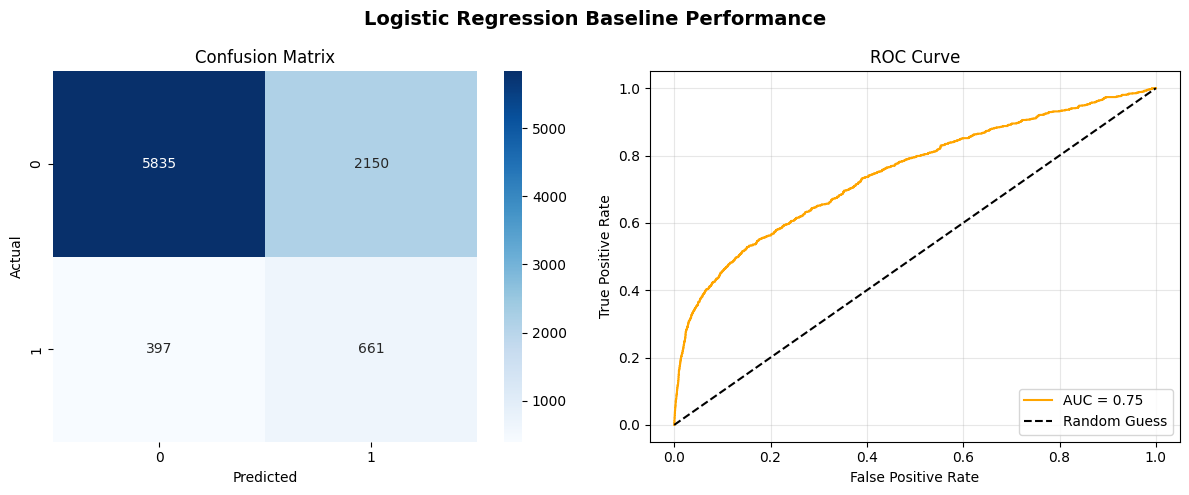


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.73      0.82      7985
           1       0.24      0.62      0.34      1058

    accuracy                           0.72      9043
   macro avg       0.59      0.68      0.58      9043
weighted avg       0.85      0.72      0.76      9043

ROC-AUC: 0.7457


In [68]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_final, y_train_res)

y_pred = log_model.predict(X_test_final)
y_proba = log_model.predict_proba(X_test_final)[:, 1]

plot_cm_and_roc(y_test, y_pred, y_proba, model_name="Logistic Regression Baseline")

**Logistic Regression PCA 95%**

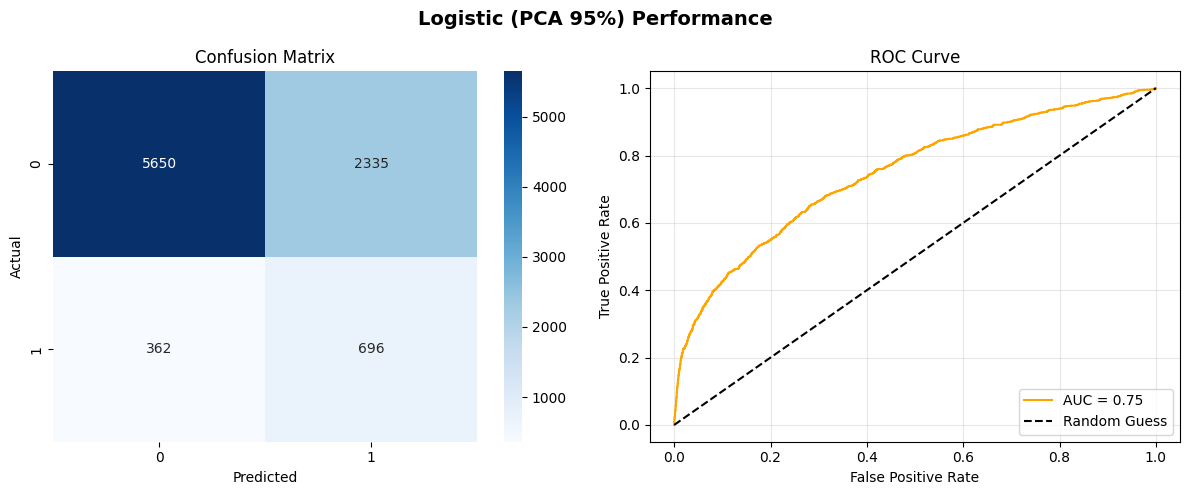


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.71      0.81      7985
           1       0.23      0.66      0.34      1058

    accuracy                           0.70      9043
   macro avg       0.58      0.68      0.57      9043
weighted avg       0.86      0.70      0.75      9043

ROC-AUC: 0.7462


In [69]:
log_model_pca = LogisticRegression(max_iter=2000, random_state=42)
log_model_pca.fit(X_train_pca, y_train_res)

y_pred_pca  = log_model_pca.predict(X_test_pca)
y_proba_pca = log_model_pca.predict_proba(X_test_pca)[:, 1]

plot_cm_and_roc(y_test, y_pred_pca, y_proba_pca, model_name="Logistic (PCA 95%)")

**Decision Tree Classifier**

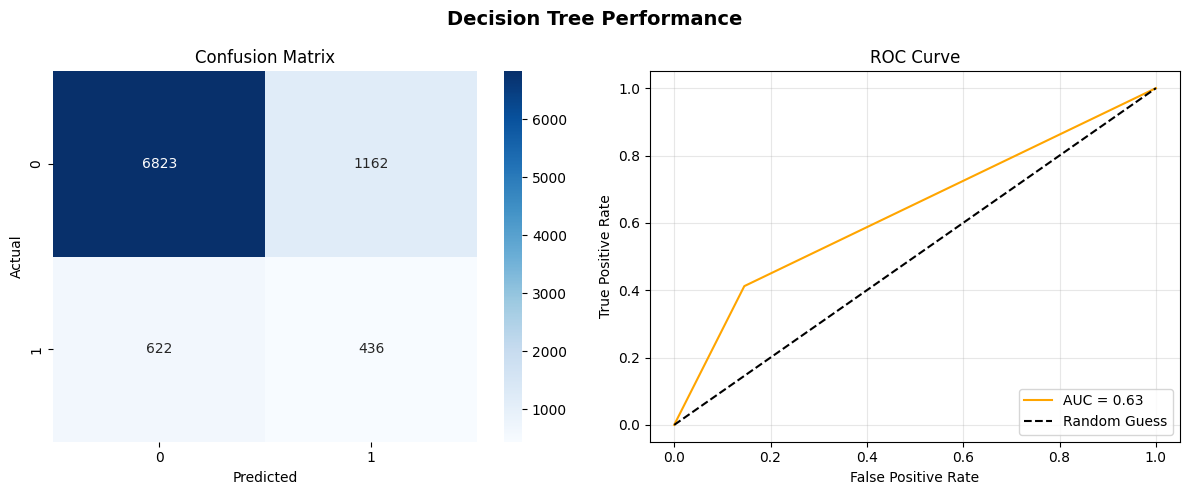


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      7985
           1       0.27      0.41      0.33      1058

    accuracy                           0.80      9043
   macro avg       0.59      0.63      0.61      9043
weighted avg       0.84      0.80      0.82      9043

ROC-AUC: 0.6333


In [70]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train_final, y_train_res)

y_pred_tree = tree_model.predict(X_test_final)
y_prob_tree = tree_model.predict_proba(X_test_final)[:, 1]

plot_cm_and_roc(y_test, y_pred_tree, y_prob_tree, model_name="Decision Tree")

**Random Forest Classifier**

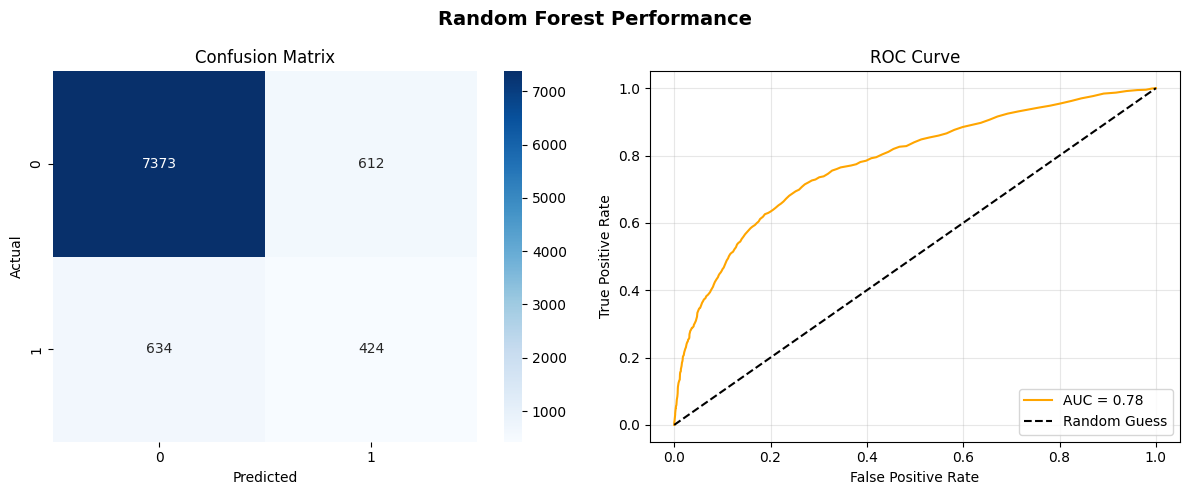


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      7985
           1       0.41      0.40      0.40      1058

    accuracy                           0.86      9043
   macro avg       0.67      0.66      0.66      9043
weighted avg       0.86      0.86      0.86      9043

ROC-AUC: 0.7805


In [71]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_final, y_train_res)

y_pred_rf = rf_model.predict(X_test_final)
y_proba_rf = rf_model.predict_proba(X_test_final)[:, 1]

plot_cm_and_roc(y_test, y_pred_rf, y_proba_rf, model_name="Random Forest")

**Naive Bayes**

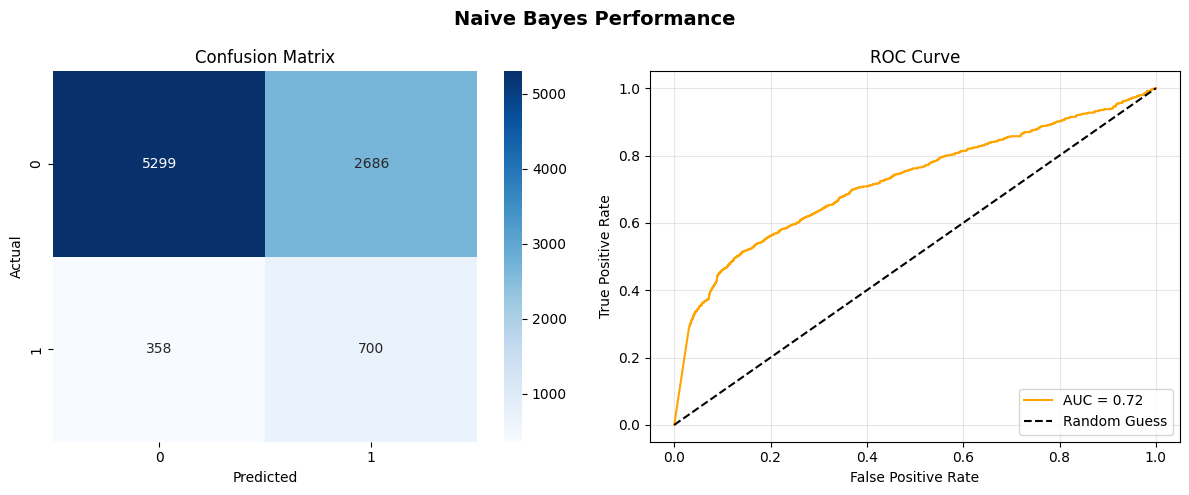


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.66      0.78      7985
           1       0.21      0.66      0.32      1058

    accuracy                           0.66      9043
   macro avg       0.57      0.66      0.55      9043
weighted avg       0.85      0.66      0.72      9043

ROC-AUC: 0.7223


In [72]:
nb_model = GaussianNB()
nb_model.fit(X_train_final, y_train_res)

y_pred_nb = nb_model.predict(X_test_final)
y_proba_nb = nb_model.predict_proba(X_test_final)[:, 1]

plot_cm_and_roc(y_test, y_pred_nb, y_proba_nb, model_name="Naive Bayes")

**XGBoost Classifier**

ROC-AUC: 0.7845949340268202


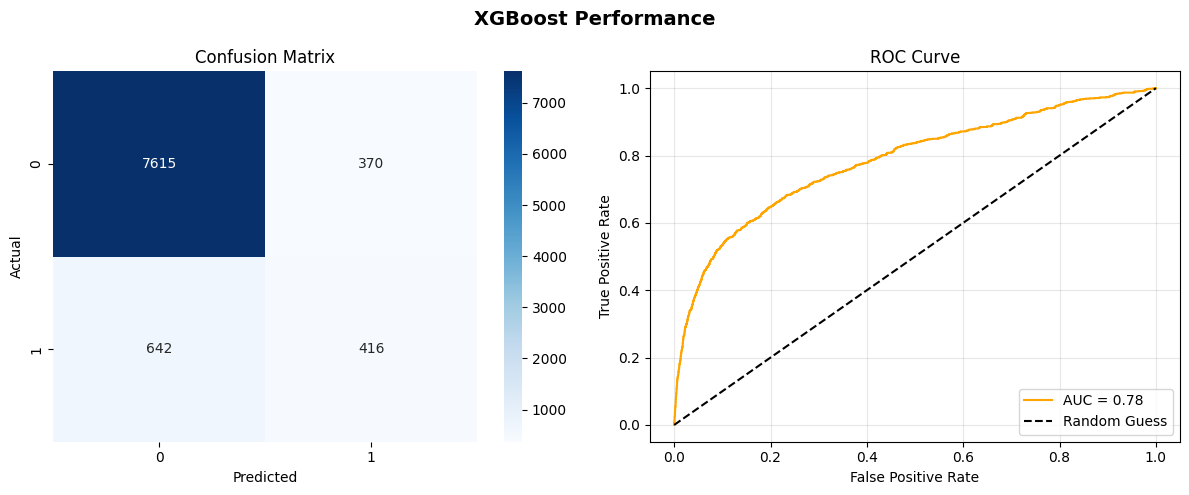


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      7985
           1       0.53      0.39      0.45      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.67      0.69      9043
weighted avg       0.88      0.89      0.88      9043

ROC-AUC: 0.7846


In [73]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

# Train
xgb_model.fit(X_train_final, y_train_res)

# Predict
y_pred_xgb = xgb_model.predict(X_test_final)
y_proba_xgb = xgb_model.predict_proba(X_test_final)[:, 1]

# Evaluate
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

plot_cm_and_roc(y_test, y_pred_xgb, y_proba_xgb, model_name="XGBoost")

**Baseline Model Summary**

| Model          | Accuracy | ROC-AUC   | Recall (Class 1) | Precision (Class 1) | F1 (Class 1) |
| -------------- | -------- | --------- | ---------------- | ------------------- | ------------ |
| Logistic       | 0.72     | 0.746     | 0.62             | 0.24                | 0.34         |
| Logistic + PCA | 0.70     | 0.746     | 0.66             | 0.23                | 0.34         |
| Decision Tree  | 0.80     | 0.633     | 0.41             | 0.27                | 0.33         |
| Random Forest  | 0.86     | 0.781     | 0.40             | 0.41                | 0.40         |
| Naive Bayes    | 0.66     | 0.722     | 0.66             | 0.21                | 0.32         |
| **XGBoost**    | **0.89** | **0.785** | 0.39             | **0.53**            | **0.45**     |

**Overall Conclusion for Baseline Models**
- XGBoost is the strongest baseline model in terms of ROC-AUC, accuracy, and minority precision.
- Random Forest performs competitively and is a strong alternative.
- Logistic Regression provides reasonable discrimination but lower precision.
- PCA does not improve performance.
- Decision Tree and Naive Bayes underperform relative to ensemble methods.

#### 4b. Hyperparameter Tuning and Cross Validation
- [Logistic Regression (Tuned + CV)](#scrollTo=OeFUoAeAiHer&line=1&uniqifier=1)
- [Random Forest (Tuned + CV)](#scrollTo=48fBkAcJiCEX&line=1&uniqifier=1)
- [XGBoost (Tuned + CV)](#scrollTo=FkUlFu4Qij7G&line=1&uniqifier=1)

**Logistic Regression (Tuned + CV)**

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'clf__C': 0.01, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best CV ROC-AUC: 0.7631550073752759
Test ROC-AUC: 0.7723517512159496
Best model saved to: /content/drive/MyDrive/models/log_best_model_20260306_2314.pkl


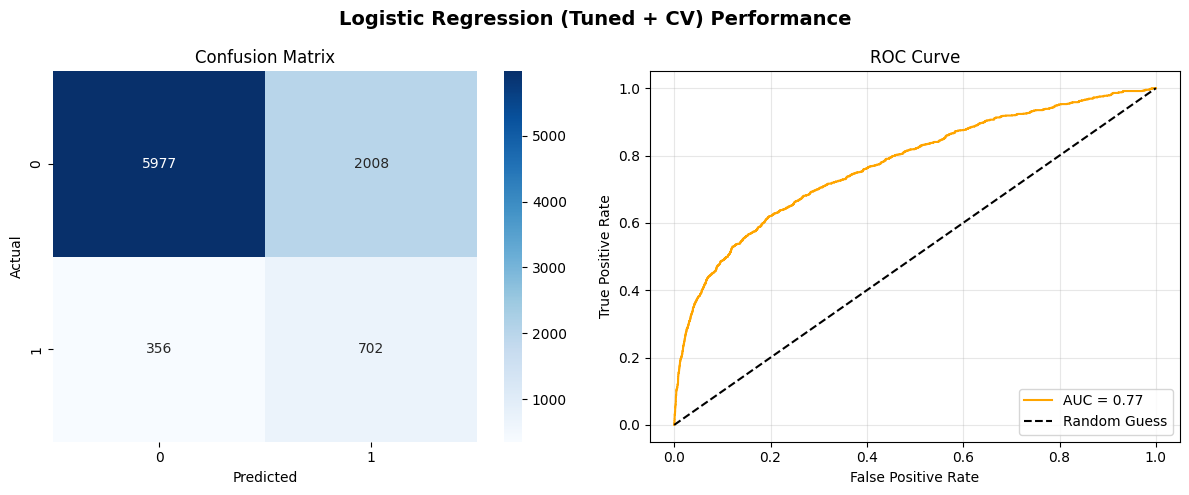


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.75      0.83      7985
           1       0.26      0.66      0.37      1058

    accuracy                           0.74      9043
   macro avg       0.60      0.71      0.60      9043
weighted avg       0.86      0.74      0.78      9043

ROC-AUC: 0.7724


In [74]:
# Preprocess: scale numeric, OHE categoricals
preprocess = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), continuous_num),
        ("bin", "passthrough", binary_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2"],
    "clf__solver": ["liblinear"],
    "clf__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_log = grid.best_estimator_
y_proba = best_log.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
save_best_model(grid, "log_best_model.pkl", add_timestamp=True)
plot_cm_and_roc(y_test, y_pred, y_proba, model_name="Logistic Regression (Tuned + CV)")

**Random Forest (Tuned + CV)**

Fitting 3 folds for each of 48 candidates, totalling 144 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'rf__max_depth': 20, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 300}
Best CV ROC-AUC: 0.7922812474190088
Test ROC-AUC: 0.8044454808342201
Best model saved to: /content/drive/MyDrive/models/rf_best_model_20260306_2340.pkl


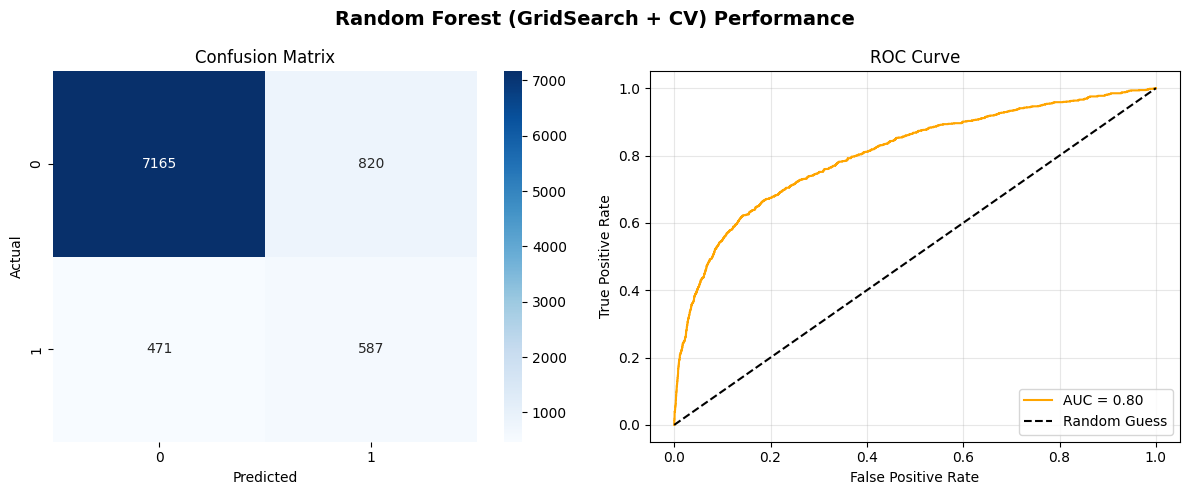


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      7985
           1       0.42      0.55      0.48      1058

    accuracy                           0.86      9043
   macro avg       0.68      0.73      0.70      9043
weighted avg       0.88      0.86      0.87      9043

ROC-AUC: 0.8044


In [75]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), continuous_num),
        ("bin", "passthrough", binary_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

param_grid_rf = {
    "rf__n_estimators": [300, 500],
    "rf__max_depth": [None, 20, 40],
    "rf__min_samples_split": [2, 10],
    "rf__min_samples_leaf": [1, 4],
    "rf__max_features": ["sqrt", "log2"],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best Params:", grid_rf.best_params_)
print("Best CV ROC-AUC:", grid_rf.best_score_)

best_rf = grid_rf.best_estimator_
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)


print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
save_best_model(grid_rf, "rf_best_model.pkl", add_timestamp=True)
plot_cm_and_roc(y_test, y_pred_rf, y_proba_rf,
                model_name="Random Forest (GridSearch + CV)")

**XGBoost (Tuned + CV)**

Fitting 3 folds for each of 144 candidates, totalling 432 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.03, 'xgb__max_depth': 6, 'xgb__min_child_weight': 1, 'xgb__n_estimators': 300, 'xgb__subsample': 0.8}
Best CV ROC-AUC: 0.8010951872336696
Test ROC-AUC: 0.8099063343012003
Best model saved to: /content/drive/MyDrive/models/xgb_best_model_20260306_2349.pkl


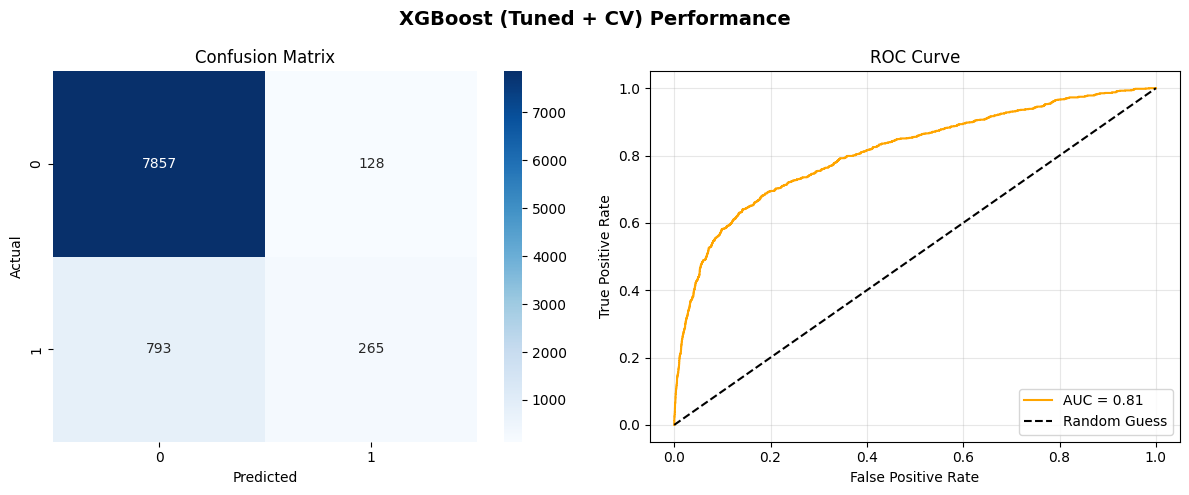


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.67      0.25      0.37      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.62      0.65      9043
weighted avg       0.88      0.90      0.88      9043

ROC-AUC: 0.8099


In [76]:
# compute imbalance weight from ORIGINAL y_train
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

preprocess = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), continuous_num),
        ("bin", "passthrough", binary_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

pipe_xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        tree_method="hist",
        n_jobs=-1
    ))
])

param_dist = {
    "xgb__n_estimators": [300, 500],
    "xgb__learning_rate": [0.03, 0.05, 0.1],
    "xgb__max_depth": [3, 4, 6],
    "xgb__min_child_weight": [1, 5],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_dist,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Best Params:", grid_xgb.best_params_)
print("Best CV ROC-AUC:", grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
save_best_model(grid_xgb, "xgb_best_model.pkl", add_timestamp=True)
plot_cm_and_roc(y_test, y_pred_xgb, y_proba_xgb, model_name="XGBoost (Tuned + CV)")

### 4c. Model Summary & Key Findings

**Baseline Models**
| Model          | Accuracy | ROC-AUC | Recall (Class 1) | Precision (Class 1) | F1 (Class 1) |
| -------------- | -------- | ------- | ---------------- | ------------------- | ------------ |
| Logistic       | 0.72     | 0.746   | 0.62             | 0.24                | 0.34         |
| Logistic + PCA | 0.70     | 0.746   | 0.66             | 0.23                | 0.34         |
| Decision Tree  | 0.80     | 0.633   | 0.41             | 0.27                | 0.33         |
| Random Forest  | 0.86     | 0.781   | 0.40             | 0.41                | 0.40         |
| Naive Bayes    | 0.66     | 0.722   | 0.66             | 0.21                | 0.32         |
| XGBoost        | 0.89     | 0.785   | 0.39             | 0.53                | 0.45         |

**Overall Model Comparison (Including Tuning)**

| Model                     | Accuracy | ROC-AUC   | Recall (Class 1) | Precision (Class 1) | F1 (Class 1) |
| ------------------------- | -------- | --------- | ---------------- | ------------------- | ------------ |
| Logistic (Baseline)       | 0.72     | 0.746     | 0.62             | 0.24                | 0.34         |
| Logistic (Tuned)          | 0.72     | 0.746     | 0.63             | 0.24                | 0.34         |
| Random Forest (Baseline)  | 0.86     | 0.781     | 0.40             | 0.41                | 0.40         |
| Random Forest (Tuned) | 0.86 | 0.804 | 0.55         | 0.42            | 0.48     |
| XGBoost (Baseline)        | 0.89     | 0.785     | 0.39             | 0.53                | 0.45         |
| XGBoost (Tuned)           | 0.90  | 0.810   | 0.25          | 0.67             | 0.37      |



**Key Findings**
- **Logistic Regression**
  - **Hyperparamter tuning** does **not** meaningfully **improve** performance
  - **ROC-AUC** remains `~0.746`
  - **Minority precision** remains low `(~0.24)`
  - Model likely **underfits** nonlinear relationships
  - Performance **limited** by linear decision boundary
- **Random Forest**
  - **Strong discrimination** ability `(ROC-AUC=0.804)`
  - Significant improvement in** minority recall** `(0.55 vs 0.40 baseline)`
  - Best **minority F1 score** (`0.48`, highest overall so far)
  - CV `(0.792`) and test `(0.804)` closely aligned - **good generalization**
  - **Strongest model** for **balanced minority** detection
- **XGBoost**
  - **Highest overall discrimination** (`ROC-AUC=0.810`, best in class)
  - **Very high minority precisio**n (`0.67`)
  - **Low minority recall** (`0.25`) at default threshold
  - Conservative prediction behavior (**fewer false positives**)
- **PCA**
  - **No** measurable performance benefit
  - Dimensionality reduction unnecessary for this dataset
  - Tree-based models unaffected by multicollinearity
- **Ensemble Methods vs Linear Models**
  - **Tree-based ensembles** clearly outperform **Logistic Regression**
  - **Random Forest** achieves best minority F1
  - **XGBoost** achieves **best ROC-AUC** and **precision**
  - **Nonlinear interactions** are important in this dataset
  - **Ensemble models** better capture **complex feature realtionships**



**Current Model Leadership**
- **Best ROC-AUC**: *XGBoost* `(0.810)`
- **Best Minority F1**: *Random Forest* `(0.48)`
- **Best Minority Precision**: *XGBoost* `(0.67)`
- **Best Minority Recall**: *Random Forest* `(0.55)`

**Final model choice now depends on business objective:**
- **Maximize detection** → *Random Forest*
- **Minimize false positives** → *XGBoost*
- **Optimize overall ranking** → *XGBoost*

## **Step 5: Critical Thinking: Ethical AI & Bias Auditing**

#### **5a. Explainability (SHAP Analysis)**

We used SHAP to interpret the tuned XGBoost model. Features are ranked by mean absolute SHAP value. SHAP values provide a global explanation by summarizing feature contributions to the model output for class 1 across the test set.

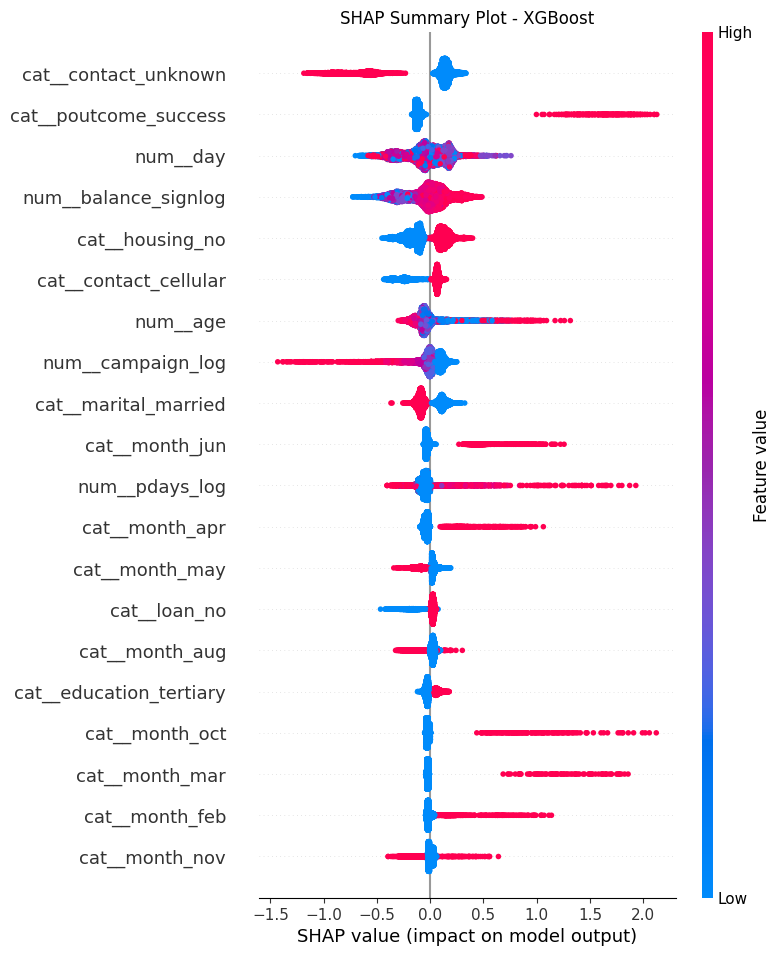

In [77]:
# Extract fitted preprocessor + fitted xgb model
pre = best_xgb.named_steps["preprocess"]
xgb = best_xgb.named_steps["xgb"]

# Transform X_test using the SAME preprocessor
X_test_enc = pre.transform(X_test)

# SHAP on the actual xgb model
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_enc)

# Feature names after preprocessing
feature_names = pre.get_feature_names_out()

# Plot
plt.figure(figsize=(14, 6))
shap.summary_plot(shap_values, X_test_enc, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot - XGBoost")
plt.show()

**Top 5 Drivers of Subscription (Class 1)**

Features are ordered by mean absolute SHAP value (importance).

1. *Contact Method* - `cat__contact_unknown`
    - **Strongest negative predictor**
    - **Unknown** contact type significantly **reduces predicted probability**
    - **Business implication**: **Data quality** and **contact transparency** are critical for campaign success
2. *Previous Outcome* - `cat__poutcome_success`
    - **Strong positive impact**
    - **Prior campaign success** strongly predicts future subscription
    - Suggests **path dependency** and b**ehavioral inertia** in customer engagement
3. *Financial Indicators* - `num__balance_signlog`, `cat__housing_no`
    - **Higher balance** increases likelihood of subscription
    - **Customers without housing loans** are more likely to subscribe
    - Indicates **financial flexibility** as a key driver
4. *Campaign Intensity* - `num__campaign_log`
    - **Higher number** of campaign attempts **reduces probability**
    - Suggests diminishing returns or customer fatigue effect
5. *Age* - `num__age`
    - **Older customers** show **higher predicted probability**
    - **Raises fairness considerations**



**Seasonality - Month Indicators**

**Months** such as:
- *October*
- *March*
- *February*
- *June*

Show strong positive SHAP values, indicating seasonal effects in campaign performance

### **5b. Model Behavior & Decision Strategy**



**XGBoost (Tuned)**
  - **ROC-AUC**: 0.810 (best ranking performance)
  - **Precision** (Class 1): 0.67
  - **Recall** (Class 1): 0.25

The model is **highly selective**:
- **Prioritizes precision over recall** at default threshold (0.5)
- Predicts **positive only** when signal is **strong**
- **Minimizes false positives**

This reflects a conservative decision policy rather than weak predictive capacity. Threshold tuning could rebalance recall/precision tradeoff.

### **5c. Model & Data Limitations**

**Class Imbalance**
- **Positive class** represents `~12%` of data
- **ROC-AUC** alone may **overstate** performance
- **Precision-Recall tradeoff** is more relevant

- **Mitigation:**
  - Addressed imbalance by reporting class-wise **precision/recall/F1** in addition to **ROC-AUC**, and by **auditing fairness** at the operating threshold `(0.5)`
  - **Compared F1 scores**
  - Evaluated **recall** and **precision** explicitly

**Overfitting Risk**
- **Cross-validation** used (**3-fold Stratified**)
- **CV ROC-AUC** (*0.801*) closely matches **Test ROC-AUC** (`0.810`)
- **Small gap** suggests **good generalization**

**Data Leakage Risk (Addressed)**
- Earlier versions used **resampling outside CV** (risk of leakage)
- This was corrected by:
  - Using **Pipeline-based preprocessing**
  - **Performing CV** properly within **training folds**

**Feature Engineering Bias**
- **OHE increases** dimensionality and may:
  - Overemphasize categorical splits
  - Introduce sparsity bias
- **Tree-based models** handle this reasonably well

### **5d. Bias Audit & Fairness Evaluation**

Potential sensitive attributes in this dataset include:
- **Age**
- **Marital status**
- **Education**
- **Loan status**

Observed Risk: **Age-Based Disparity**

**SHAP shows:**
- **Higher age** increases **predicted probability**
- **Younger customers** are systematically **predicted lower**
- This may create **age-based discrimination** in marketing allocation.

**Quantitative Fairness Check**

We audited age-based bias using:
- **Demographic Parity Difference**
- **Equal Opportunity**
- **False Positive Rate Difference**

In [78]:
def _false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    denom = fp + tn
    return fp / denom if denom else 0.0

def run_bias_audit_age(model, X_test, y_test, age_cut=35, threshold=0.5):
    # predictions
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    y_true = np.asarray(y_test)

    # group masks
    mask_priv = (X_test["age"].values >= age_cut)   # privileged: older
    mask_unpriv = ~mask_priv                        # unprivileged: younger

    # Demographic parity (positive prediction rate)
    p_pos_priv = y_pred[mask_priv].mean() if mask_priv.any() else np.nan
    p_pos_unpriv = y_pred[mask_unpriv].mean() if mask_unpriv.any() else np.nan
    dp_diff = p_pos_unpriv - p_pos_priv

    # Equal opportunity (TPR/Recall for class 1)
    tpr_priv = recall_score(y_true[mask_priv], y_pred[mask_priv], zero_division=0) if mask_priv.any() else np.nan
    tpr_unpriv = recall_score(y_true[mask_unpriv], y_pred[mask_unpriv], zero_division=0) if mask_unpriv.any() else np.nan
    eo_diff = tpr_unpriv - tpr_priv

    # False positive rate
    fpr_priv = _false_positive_rate(y_true[mask_priv], y_pred[mask_priv]) if mask_priv.any() else np.nan
    fpr_unpriv = _false_positive_rate(y_true[mask_unpriv], y_pred[mask_unpriv]) if mask_unpriv.any() else np.nan
    fpr_diff = fpr_unpriv - fpr_priv

    # Pretty report table
    report = pd.DataFrame({
        "Group": [f"age < {age_cut}", f"age ≥ {age_cut}"],
        "Count": [mask_unpriv.sum(), mask_priv.sum()],
        "P(ŷ=1)": [p_pos_unpriv, p_pos_priv],
        "TPR/Recall (y=1)": [tpr_unpriv, tpr_priv],
        "FPR (y=0)": [fpr_unpriv, fpr_priv],
    })

    gaps = {
        "Demographic Parity Diff (younger - older)": dp_diff,
        "Equal Opportunity Diff (younger - older)": eo_diff,
        "FPR Diff (younger - older)": fpr_diff,
    }

    return report, gaps

In [79]:
# Example on XGBoost (pipeline)
report, gaps = run_bias_audit_age(best_xgb, X_test, y_test, age_cut=35, threshold=0.5)

print(report.to_string(index=False))
print("\n")
for k, v in gaps.items():
    print(f"{k}: {v:.4f}")

   Group  Count   P(ŷ=1)  TPR/Recall (y=1)  FPR (y=0)
age < 35   2933 0.050801          0.256410   0.019269
age ≥ 35   6110 0.039935          0.247006   0.014517


Demographic Parity Diff (younger - older): 0.0109
Equal Opportunity Diff (younger - older): 0.0094
FPR Diff (younger - older): 0.0048


**Audit Interpretation**

The fairness audit evaluates potential age-based disparities between customers aged `<35` (younger group) and `≥ 35` (older group) using three metrics:
- **Demographic parity difference** indicates whether younger vs older customers are predicted “yes” at different rates
  - Observed DP (younger - older): **0.0109**
  - This indicates that **younger customers** receive **positive predictions** at a rate approximately **1.1 percentage points higher** than older customers
  - The difference is **small and close to zero**, suggesting **no substantial imbalance** in overall positive prediction allocation between the two age groups
- **Equal opportunity difference** checks whether the model misses positives more in one group (recall gap).
  - Observed EO (younger - older): **0.0094**
  - This means **younger customers** have a recall rate approximately **0.9 percentage points higher** than **older customers**
  - The **smaller magnitude** of this gap indicates that the model **does not disproportionately miss true** subscribers in either age group.
  - **Equal opportunity** appears approximately satisfied
- **FPR difference** checks whether one group gets more false positives.
  - Observed FPR diff (younger - older): **0.0048**
  - This indicates that **younger customers** experience a false positive rate approximately **0.5 percentage points higher** than older customers.
  - The **magnitude is minimal** and unlikely to represent meaningful discriminatory harm

**Overall Fairness Assessment**

- All **three fairness gaps are close to zero** (≈1% or less), indicating approximate age-based parity at the 0.5 threshold
- Although SHAP showed age influences predictions, the **quantitative audit confirms this does not result in meaningful performance disparities** between younger and older customers
- While high **ROC-AUC (0.81) does not guarantee fairness**, the current evidence suggests **no material age-based bias**, though ongoing monitoring is recommended

### **5e. Proposed Mitigation Strategies**

If unfairness is detected, possible mitigation:
- **Threshold Adjustment per Group**
  - Apply group-specific thresholds to equalize recall (Equal Opportunity)
- **Reweighting During Training**
  - Use fairness-aware weighting to penalize unequal treatment.
- **Remove or Regularize Sensitive Features**
  - If age introduces harmful bias, consider:
    - Removing age
    - Or reducing its influence
- **Post-Processing Calibration**
  - Adjust predicted probabilities to satisfy fairness constraints

> Mitigations can reduce disparities but may change precision/recall; therefore they should be evaluated using both performance and fairness metrics



### **5f. Ethical Reflection**

While the model performs strongly (ROC-AUC 0.81), ethical deployment requires:

- **Monitoring age-related disparities**
- **Avoiding discriminatory targeting**
- **Ensuring transparency in campaign selection**
- **Periodic fairness audits**

High precision alone does not imply ethical fairness

## **Step 6: Final Presentation & Communication**

### **6a. Powerpoint Presentations**
- **Technical deck**: [technical_presentation.pptx](https://github.com/orlyrevalo/AIMCapstoneProject/blob/main/reports/technical_presentation.pptx)
- **Business deck**: [business_presentation.pptx](https://github.com/orlyrevalo/AIMCapstoneProject/blob/main/reports/business_presentation.pptx)

## **Step 7: GitHub Profile & Upload**


### **7a. Github Repository Link**

**Github Repo Link**: [https://github.com/orlyrevalo/AIMCapstoneProject](https://github.com/orlyrevalo/AIMCapstoneProject)




### **7b. Project Structure**

```
AIMCapstoneProject/
│
├── README.md                    
├── requirements.txt
├── .gitignore            
│
├── notebooks/
│   └── Orly_Revalo_CapstoneProject.ipynb
│
├── data/                 
│   └── bank-full.csv     
│
├── docs/                 
│   └── data_dictionary.md     
│
├── models/
│   ├── log_best_model_xxxxxxxx_xxxx.pkl
│   ├── rf_best_model_xxxxxxxx_xxxx.pkl
│   └── xgb_best_model_xxxxxxxx_xxxx.pkl
│
├── reports/
│   ├── final_report.pdf
│   ├── business_presentation.pptx
│   └── technical_presentation.pptx       
│
└── src/                     
    └── __init__.py
```
---